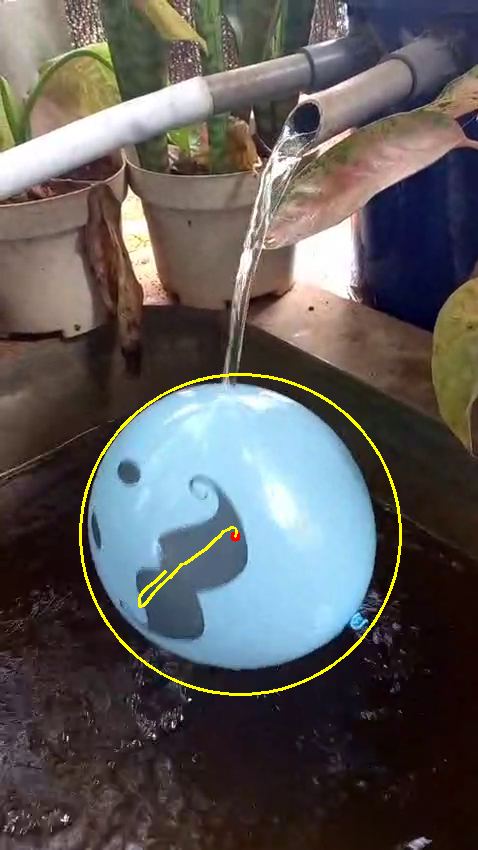

In [ ]:
import cv2
import numpy as np
from collections import deque
from google.colab.patches import cv2_imshow
from IPython.display import clear_output

pts = deque(maxlen=32)
cap = cv2.VideoCapture('balonvanderpol2.mp4')

# RENTANG BIRU BARU
blueLower = (90, 70, 50)
blueUpper = (130, 255, 255)

while True:
    ret, frame = cap.read()
    if not ret: break

    # 1. Pra-pemrosesan
    blurred = cv2.GaussianBlur(frame, (11, 11), 0)
    hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)

    # 2. Masking Biru
    mask = cv2.inRange(hsv, blueLower, blueUpper)
    mask = cv2.erode(mask, None, iterations=2)
    mask = cv2.dilate(mask, None, iterations=2)

    # 3. Cari Kontur
    cnts, _ = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    center = None

    if len(cnts) > 0:
        c = max(cnts, key=cv2.contourArea)
        ((x, y), radius) = cv2.minEnclosingCircle(c)
        M = cv2.moments(c)
        if M["m00"] != 0:
            center = (int(M["m10"] / M["m00"]), int(M["m01"] / M["m00"]))
            if radius > 5: # Kecilkan sedikit agar lebih sensitif
                cv2.circle(frame, (int(x), int(y)), int(radius), (0, 255, 255), 2)
                cv2.circle(frame, center, 5, (0, 0, 255), -1)

    # 4. Gambar Jejak
    pts.appendleft(center)
    for i in range(1, len(pts)):
        if pts[i - 1] is None or pts[i] is None: continue
        cv2.line(frame, pts[i - 1], pts[i], (0, 255, 255), 2)

    # 5. Tampilkan di Colab dengan rapi
    cv2_imshow(frame)
    clear_output(wait=True)

cap.release()

Memproses video... Menggunakan FPS: 30.03164506677977


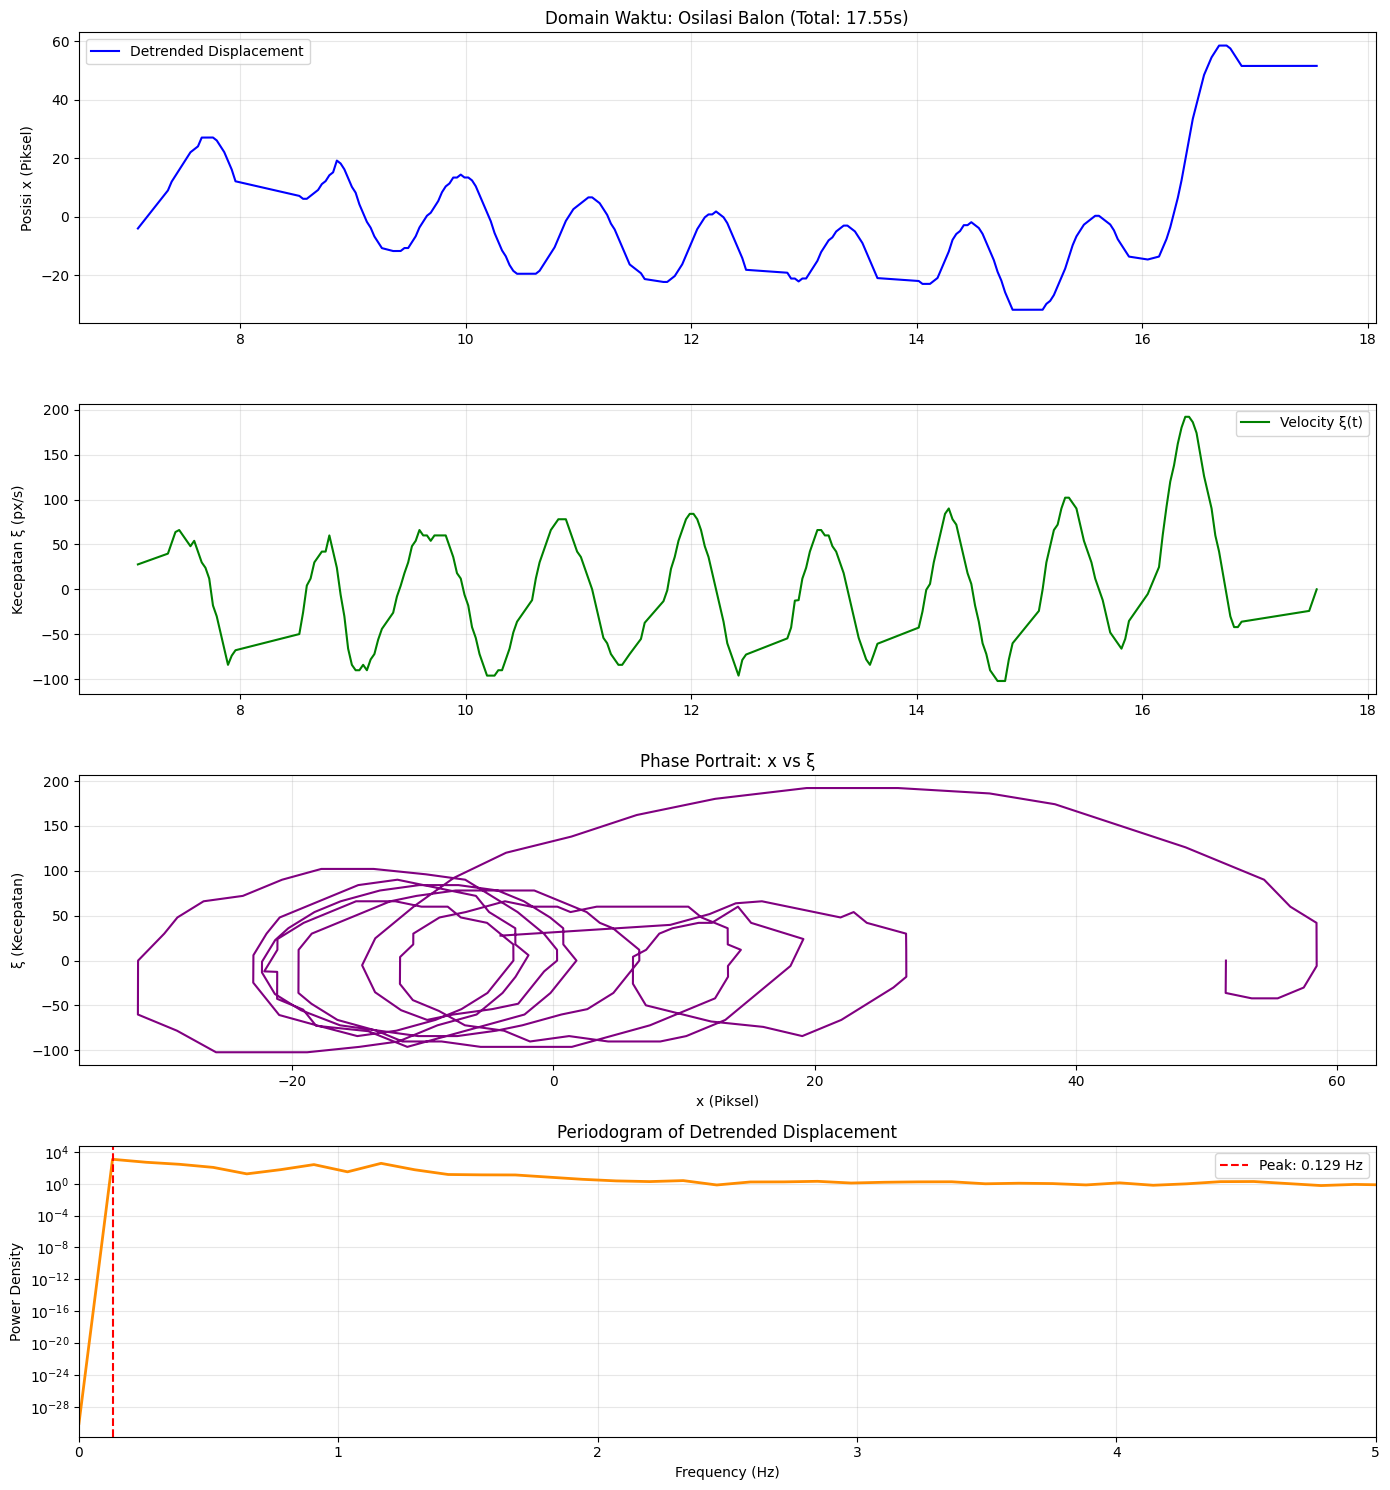


HASIL ANALISIS FREKUENSI:
Peak Frequency (f)    : 0.1294 Hz
Angular Frequency (ω) : 0.8133 rad/s
Jumlah Osilasi Terdeteksi: ~2.3 (Target: 13)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [ ]:
import cv2
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from scipy import signal
from google.colab.patches import cv2_imshow
from google.colab import files
import os

# 1. KONFIGURASI VIDEO
video_path = 'balonvanderpol.mp4'
output_video = 'analisis_vanderpol_lengkaphitam.mp4'

if not os.path.exists(video_path):
    print(f"Error: File {video_path} tidak ditemukan!")
else:
    cap = cv2.VideoCapture(video_path)
    fps_original = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Setup VideoWriter
    fourcc = cv2.VideoWriter_fourcc(*'MP4V')
    out = cv2.VideoWriter(output_video, fourcc, fps_original, (width, height))

    # Parameter Pelacakan
    pts = deque(maxlen=20)
    pos_history = deque(maxlen=10)
    list_x, time_steps = [], []
    blueLower = (90, 70, 50)
    blueUpper = (130, 255, 255)

    print(f"Memproses video... Menggunakan FPS: {fps_original}")

    frame_count = 0
    max_frames = int(18 * fps_original) # Batasan 18 detik

    while frame_count < max_frames:
        ret, frame = cap.read()
        if not ret: break
        frame_count += 1

        # Image Processing
        blurred = cv2.GaussianBlur(frame, (11, 11), 0)
        hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
        mask = cv2.inRange(hsv, blueLower, blueUpper)
        mask = cv2.erode(mask, None, iterations=3)
        mask = cv2.dilate(mask, None, iterations=3)

        cnts, _ = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        center = None

        if len(cnts) > 0:
            c = max(cnts, key=cv2.contourArea)
            if cv2.contourArea(c) > 500:
                M = cv2.moments(c)
                if M["m00"] != 0:
                    curr_x = int(M["m10"] / M["m00"])
                    curr_y = int(M["m01"] / M["m00"])
                    pos_history.append((curr_x, curr_y))

                    avg_x = int(np.mean([p[0] for p in pos_history]))
                    avg_y = int(np.mean([p[1] for p in pos_history]))
                    center = (avg_x, avg_y)

                    list_x.append(avg_x)
                    time_steps.append(frame_count / fps_original)

                    # Visualisasi di Video
                    cv2.drawMarker(frame, center, (0, 255, 0), cv2.MARKER_CROSS, 15, 2)
                    cv2.putText(frame, f"t: {time_steps[-1]:.2f}s", (avg_x - 40, avg_y - 30),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        out.write(frame)

    cap.release()
    out.release()

    # --- 2. ANALISIS PERIODOGRAM (DETRENDED) ---
    # Detrending: Menghilangkan drift agar osilasi berpusat di nol
    x_detrended = signal.detrend(list_x)

    # Menghitung Power Spectral Density menggunakan Periodogram
    frequencies, psd = signal.periodogram(x_detrended, fps_original)

    # Cari Peak Frequency (f) dan Omega (w)
    peak_idx = np.argmax(psd)
    f_peak = frequencies[peak_idx]
    omega_peak = 2 * np.pi * f_peak

    # --- 3. PLOTTING LENGKAP ---
    plt.figure(figsize=(14, 15))

    # Plot 1: Displacement (x) terhadap Waktu
    plt.subplot(4, 1, 1)
    plt.plot(time_steps, x_detrended, color='blue', label='Detrended Displacement')
    plt.title(f'Domain Waktu: Osilasi Balon (Total: {time_steps[-1]:.2f}s)')
    plt.ylabel('Posisi x (Piksel)')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Plot 2: Kecepatan (xi)
    xi = np.diff(list_x) / np.diff(time_steps)
    xi = np.insert(xi, 0, 0)
    xi_smooth = np.convolve(xi, np.ones(5)/5, mode='same')
    plt.subplot(4, 1, 2)
    plt.plot(time_steps, xi_smooth, color='green', label='Velocity ξ(t)')
    plt.ylabel('Kecepatan ξ (px/s)')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Plot 3: Phase Portrait
    plt.subplot(4, 1, 3)
    plt.plot(x_detrended, xi_smooth, color='purple')
    plt.title('Phase Portrait: x vs ξ')
    plt.xlabel('x (Piksel)')
    plt.ylabel('ξ (Kecepatan)')
    plt.grid(True, alpha=0.3)

    # Plot 4: Periodogram
    plt.subplot(4, 1, 4)
    plt.semilogy(frequencies, psd, color='darkorange', lw=2)
    plt.axvline(f_peak, color='red', linestyle='--', label=f'Peak: {f_peak:.3f} Hz')
    plt.title('Periodogram of Detrended Displacement')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power Density')
    plt.xlim(0, 5) # Fokus pada range frekuensi rendah
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Output Hasil Akhir
    print("\n" + "="*30)
    print(f"HASIL ANALISIS FREKUENSI:")
    print(f"Peak Frequency (f)    : {f_peak:.4f} Hz")
    print(f"Angular Frequency (ω) : {omega_peak:.4f} rad/s")
    print(f"Jumlah Osilasi Terdeteksi: ~{f_peak * 18:.1f} (Target: 13)")
    print("="*30)

    files.download(output_video)
    plt.savefig('hasil_analisis_vanderpolhitam.png')

Memproses video... Target: ~18 detik analisis.


ValueError: x and y must have same first dimension, but have shapes (1,) and (5,)

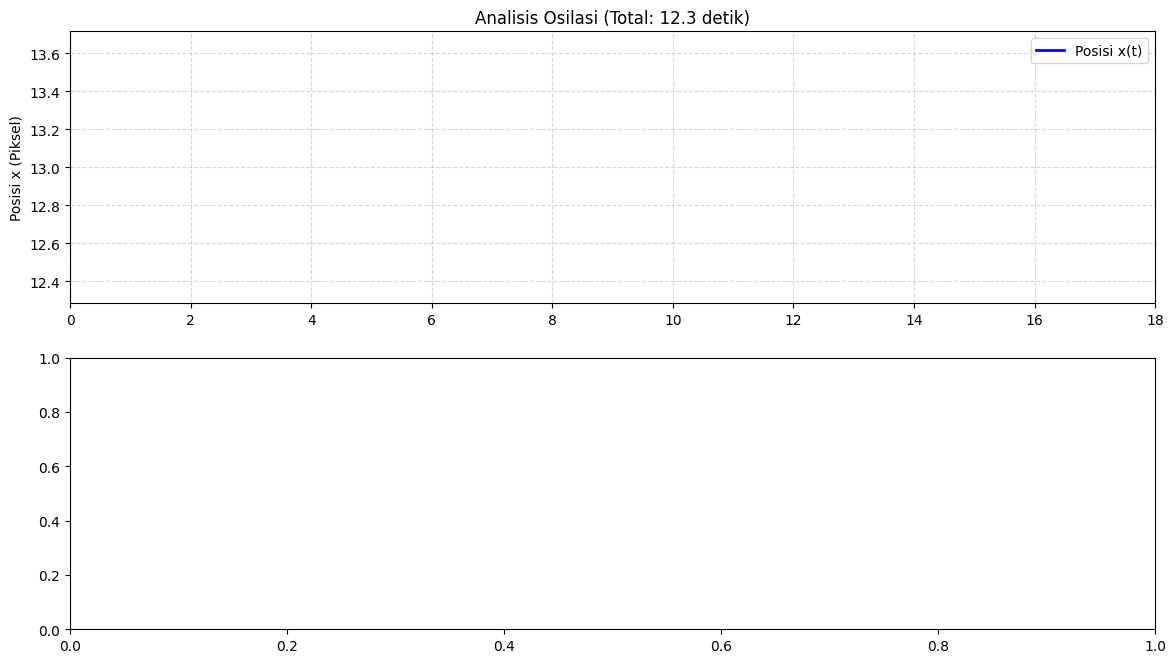

In [ ]:
import cv2
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import files
import os

# 1. KONFIGURASI FILE
video_path = 'bolavanderpol3.mp4'
output_video = 'analisis_vanderpol_18detik.mp4'

if not os.path.exists(video_path):
    print(f"Error: File {video_path} tidak ditemukan!")
else:
    cap = cv2.VideoCapture(video_path)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Ambil FPS asli video untuk perhitungan waktu yang akurat
    fps_original = cap.get(cv2.CAP_PROP_FPS)

    # Setup Penyimpanan Video
    fourcc = cv2.VideoWriter_fourcc(*'MP4V')
    out = cv2.VideoWriter(output_video, fourcc, fps_original, (width, height))

    # Parameter Tracking
    pts = deque(maxlen=20)
    pos_history = deque(maxlen=10) # Untuk kestabilan x
    list_x, time_steps = [], []

    # Range Warna Biru (HSV)
    blueLower = (90, 70, 50)
    blueUpper = (130, 255, 255)

    print(f"Memproses video... Target: ~18 detik analisis.")

    frame_count = 0
    # Batasi frame jika ingin tepat 18 detik (18 * fps)
    max_frames = int(18 * fps_original)

    while frame_count < max_frames:
        ret, frame = cap.read()
        if not ret: break

        frame_count += 1

        # Image Processing
        blurred = cv2.GaussianBlur(frame, (11, 11), 0)
        hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
        mask = cv2.inRange(hsv, blueLower, blueUpper)
        mask = cv2.erode(mask, None, iterations=3)
        mask = cv2.dilate(mask, None, iterations=3)

        cnts, _ = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        center = None

        if len(cnts) > 0:
            c = max(cnts, key=cv2.contourArea)
            if cv2.contourArea(c) > 500:
                M = cv2.moments(c)
                if M["m00"] != 0:
                    curr_x = int(M["m10"] / M["m00"])
                    curr_y = int(M["m01"] / M["m00"])
                    pos_history.append((curr_x, curr_y))

                    # Rata-rata posisi x agar grafik halus
                    avg_x = int(np.mean([p[0] for p in pos_history]))
                    avg_y = int(np.mean([p[1] for p in pos_history]))
                    center = (avg_x, avg_y)

                    list_x.append(avg_x)
                    # Hitung waktu berdasarkan frame ke-n dan FPS
                    time_steps.append(frame_count / fps_original)

                    # Visualisasi Marker
                    cv2.drawMarker(frame, center, (0, 255, 0), cv2.MARKER_CROSS, 15, 2)
                    cv2.putText(frame, f"t: {time_steps[-1]:.2f}s", (avg_x - 40, avg_y - 30),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        out.write(frame)

    cap.release()
    out.release()

    # --- 2. ANALISIS MATEMATIS & PLOTTING ---
    # Menghitung Kecepatan xi (dx/dt)
    xi = np.diff(list_x) / np.diff(time_steps)
    xi = np.insert(xi, 0, 0)
    xi_smooth = np.convolve(xi, np.ones(5)/5, mode='same') # Filter noise kecepatan

    plt.figure(figsize=(14, 12))

    # Plot 1: Posisi x(t) - Domain Waktu 18 Detik
    plt.subplot(3, 1, 1)
    plt.plot(time_steps, list_x, color='blue', lw=2, label='Posisi x(t)')
    plt.title(f'Analisis Osilasi (Total: {time_steps[-1]:.1f} detik)')
    plt.ylabel('Posisi x (Piksel)')
    plt.xlim(0, 18) # Membatasi sumbu waktu ke 18 detik
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()

    # Plot 2: Kecepatan xi(t) - Domain Waktu
    plt.subplot(3, 1, 2)
    plt.plot(time_steps, xi_smooth, color='green', lw=1.5, label='Kecepatan ξ(t)')
    plt.ylabel('Kecepatan ξ (Piksel/s)')
    plt.xlim(0, 18)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    # Plot 3: Phase Portrait (x vs xi)
    plt.subplot(3, 1, 3)
    plt.plot(list_x, xi_smooth, color='purple', lw=1)
    plt.xlabel('Posisi x')
    plt.ylabel('Kecepatan ξ')
    plt.title('Phase Space (Karakteristik Van der Pol)')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.savefig('grafik_18detik.png')

    print(f"Analisis Selesai. Total data poin: {len(list_x)}")
    files.download(output_video)
    files.download('grafik_18detik.png')

Analyzing Water Stream Oscillation... FPS: 30.031641377598845


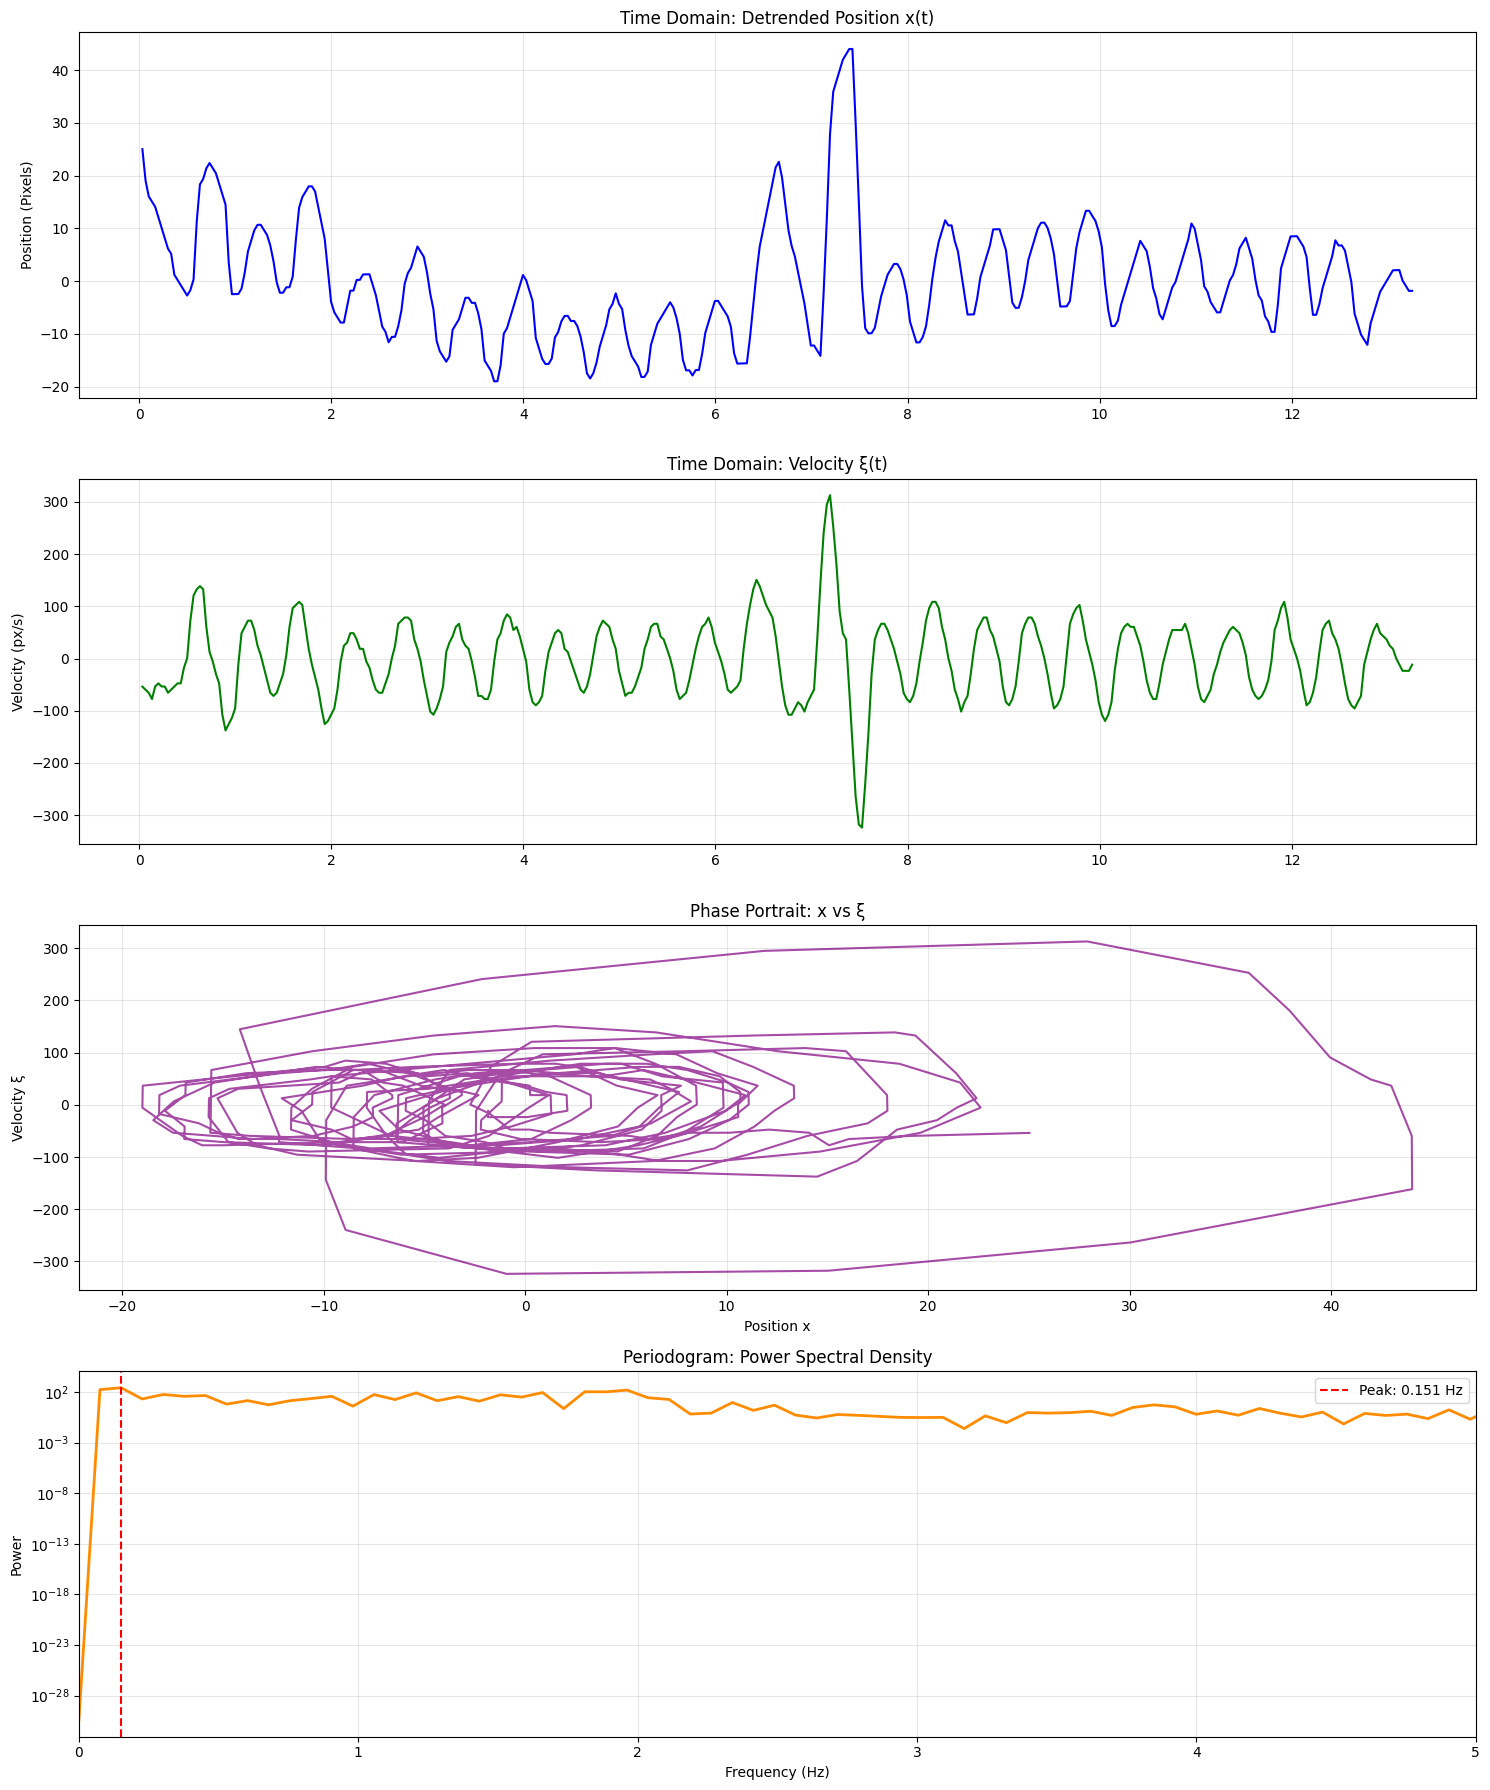


Final Analysis Results:
Peak Frequency: 0.1509 Hz
Angular Frequency (ω): 0.9482 rad/s


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [ ]:
import cv2
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from scipy import signal
from google.colab.patches import cv2_imshow
from google.colab import files
import os

# 1. VIDEO CONFIGURATION
video_path = 'bolavanderpol3.mp4'
output_video = 'water_stream_vanderpol_analysis.mp4'

if not os.path.exists(video_path):
    print(f"Error: File {video_path} not found!")
else:
    cap = cv2.VideoCapture(video_path)
    fps_original = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'MP4V')
    out = cv2.VideoWriter(output_video, fourcc, fps_original, (width, height))

    # Tracking Parameters
    pts = deque(maxlen=30)          # Red trailing tracker length
    pos_history = deque(maxlen=10)
    list_x, time_steps = [], []

    # Zone restricted to the middle of the video dimensions (40% to 60% height)
    zone_top = int(height * 0.4)
    zone_bottom = int(height * 0.6)

    # HSV Range for Water Reflections (Bright Highlights)
    waterLower = (0, 0, 200)
    waterUpper = (180, 50, 255)

    print(f"Analyzing Water Stream Oscillation... FPS: {fps_original}")

    frame_count = 0
    max_frames = int(18 * fps_original)

    while frame_count < max_frames:
        ret, frame = cap.read()
        if not ret: break
        frame_count += 1

        # Image Processing
        blurred = cv2.GaussianBlur(frame, (7, 7), 0)
        hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
        mask = cv2.inRange(hsv, waterLower, waterUpper)

        # Filter only the center zone
        full_mask = np.zeros_like(mask)
        full_mask[zone_top:zone_bottom, :] = mask[zone_top:zone_bottom, :]

        cnts, _ = cv2.findContours(full_mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        center = None

        if len(cnts) > 0:
            c = max(cnts, key=cv2.contourArea)
            if cv2.contourArea(c) > 20:
                M = cv2.moments(c)
                if M["m00"] != 0:
                    curr_x = int(M["m10"] / M["m00"])
                    curr_y = int(M["m01"] / M["m00"])
                    pos_history.append((curr_x, curr_y))

                    avg_x = int(np.mean([p[0] for p in pos_history]))
                    avg_y = int(np.mean([p[1] for p in pos_history]))
                    center = (avg_x, avg_y)

                    list_x.append(avg_x)
                    time_steps.append(frame_count / fps_original)

                    # --- VISUALIZATION ---
                    # 1. Yellow Circle (Ring)
                    cv2.circle(frame, center, 20, (0, 255, 255), 2)
                    # 2. Red Dot
                    cv2.circle(frame, center, 5, (0, 0, 255), -1)
                    # 3. Text coordinates
                    cv2.putText(frame, f"x:{avg_x}", (avg_x + 25, avg_y),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

        # 4. Red Tracker Path (Trailing Line)
        pts.appendleft(center)
        for i in range(1, len(pts)):
            if pts[i - 1] is None or pts[i] is None: continue
            cv2.line(frame, pts[i - 1], pts[i], (0, 0, 255), 2)

        out.write(frame)

    cap.release()
    out.release()

    # --- 2. SCIENTIFIC ANALYSIS ---
    if len(list_x) > 10:
        # Detrend position x
        x_detrended = signal.detrend(list_x)

        # Calculate Velocity (ksi)
        dt = 1.0 / fps_original
        ksi = np.diff(x_detrended) / dt
        ksi = np.insert(ksi, 0, 0) # Align length with x

        # Smooth ksi for cleaner phase portrait
        ksi_smooth = np.convolve(ksi, np.ones(5)/5, mode='same')

        # Calculate Periodogram
        frequencies, psd = signal.periodogram(x_detrended, fps_original)
        peak_idx = np.argmax(psd)
        f_peak = frequencies[peak_idx]

        # --- 3. PLOTTING ---
        plt.figure(figsize=(15, 18))

        # Plot 1: Position x vs Time
        plt.subplot(4, 1, 1)
        plt.plot(time_steps, x_detrended, color='blue', lw=1.5)
        plt.title('Time Domain: Detrended Position x(t)')
        plt.ylabel('Position (Pixels)')
        plt.grid(True, alpha=0.3)

        # Plot 2: Velocity ksi vs Time
        plt.subplot(4, 1, 2)
        plt.plot(time_steps, ksi_smooth, color='green', lw=1.5)
        plt.title('Time Domain: Velocity ξ(t)')
        plt.ylabel('Velocity (px/s)')
        plt.grid(True, alpha=0.3)

        # Plot 3: Phase Portrait (x vs ksi)
        plt.subplot(4, 1, 3)
        plt.plot(x_detrended, ksi_smooth, color='purple', alpha=0.7)
        plt.title('Phase Portrait: x vs ξ')
        plt.xlabel('Position x')
        plt.ylabel('Velocity ξ')
        plt.grid(True, alpha=0.3)

        # Plot 4: Periodogram
        plt.subplot(4, 1, 4)
        plt.semilogy(frequencies, psd, color='darkorange', lw=2)
        plt.axvline(f_peak, color='red', linestyle='--', label=f'Peak: {f_peak:.3f} Hz')
        plt.title('Periodogram: Power Spectral Density')
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Power')
        plt.xlim(0, 5) # Focus on low-frequency oscillations
        plt.legend()
        plt.grid(True, which="both", alpha=0.3)

        plt.tight_layout()
        plt.show()
        plt.savefig('vanderpol_full_analysis.png')

        print(f"\nFinal Analysis Results:")
        print(f"Peak Frequency: {f_peak:.4f} Hz")
        print(f"Angular Frequency (ω): {2 * np.pi * f_peak:.4f} rad/s")

    files.download(output_video)

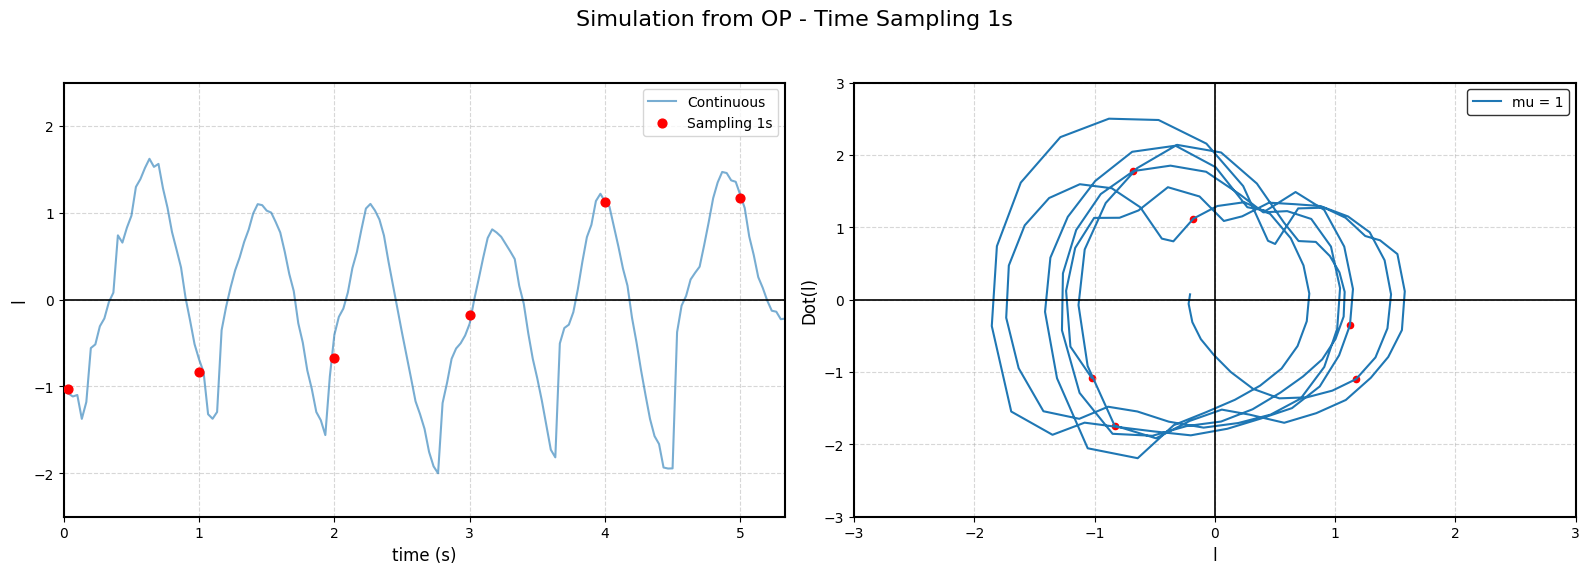

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from scipy import signal
from google.colab import files
import os

# 1. KONFIGURASI VIDEO & DATA
video_path = 'balonaja.mp4'
output_video = 'analisis_vanderpol_sampling_1s.mp4'

if not os.path.exists(video_path):
    print(f"Error: File {video_path} tidak ditemukan!")
else:
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*'MP4V')
    out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

    list_x, time_steps = [], []
    blueLower, blueUpper = (90, 70, 50), (130, 255, 255)

    while True:
        ret, frame = cap.read()
        if not ret: break

        hsv = cv2.cvtColor(cv2.GaussianBlur(frame, (11, 11), 0), cv2.COLOR_BGR2HSV)
        mask = cv2.dilate(cv2.erode(cv2.inRange(hsv, blueLower, blueUpper), None, iterations=3), None, iterations=3)
        cnts, _ = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(cnts) > 0:
            c = max(cnts, key=cv2.contourArea)
            if cv2.contourArea(c) > 500:
                M = cv2.moments(c)
                if M["m00"] != 0:
                    curr_x = M["m10"] / M["m00"]
                    list_x.append(curr_x)
                    time_steps.append(len(list_x) / fps)
                    cv2.circle(frame, (int(curr_x), int(M["m01"]/M["m00"])), 5, (0, 0, 255), -1)
        out.write(frame)

    cap.release()
    out.release()

    # --- 2. ANALISIS MATEMATIKA & SAMPLING 1 DETIK ---
    if len(list_x) > 10:
        x_norm = signal.detrend(list_x)
        x_norm = 2 * (x_norm / np.max(np.abs(x_norm)))

        # Data halus untuk garis kontinu
        x_smooth = signal.savgol_filter(x_norm, 11, 3)
        dt = 1/fps
        v_smooth = np.gradient(x_smooth, dt)
        v_norm = 2.5 * (v_smooth / np.max(np.abs(v_smooth)))

        # FILTERING DATA UNTUK SAMPLING 1 DETIK (Diskritisasi per 1s)
        time_steps = np.array(time_steps)
        # Ambil indeks di mana waktu mendekati kelipatan 1.0 detik
        indices_1s = [np.abs(time_steps - t).argmin() for t in np.arange(0, time_steps[-1], 1.0)]
        t_1s = time_steps[indices_1s]
        x_1s = x_smooth[indices_1s]

        # --- 3. PLOTTING (WIDE WAVEFORM & DISCRETE DOTS) ---
        plt.style.use('default')
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle('Simulation from OP - Time Sampling 1s', fontsize=16)

        # Plot 1: time vs l (Dibuat LEBIH LEBAR)
        ax1.plot(time_steps, x_norm, color='#1f77b4', lw=1.5, alpha=0.6, label='Continuous')
        # Diskritisasi: Marker 'o' hanya muncul setiap 1 detik
        ax1.scatter(t_1s, x_1s, color='red', s=40, zorder=3, label='Sampling 1s')

        ax1.set_xlabel('time (s)', fontsize=12)
        ax1.set_ylabel('l', fontsize=12)

        # Mengatur batas X agar gelombang terlihat lebih lebar (zoom ke durasi tertentu, misal 0-20s)
        ax1.set_xlim(0, min(20, time_steps[-1]))
        ax1.set_ylim(-2.5, 2.5)
        ax1.grid(True, which='both', linestyle='--', alpha=0.5)
        ax1.legend(loc='upper right')
        for spine in ax1.spines.values(): spine.set_linewidth(1.5)

        # Plot 2: Dot(l) vs l (Phase Portrait)
        ax2.plot(x_smooth, v_norm, color='#1f77b4', lw=1.5, label='mu = 1')
        ax2.scatter(x_smooth[indices_1s], v_norm[indices_1s], color='red', s=20) # Dot diskrit di orbit
        ax2.set_xlabel('l', fontsize=12)
        ax2.set_ylabel('Dot(l)', fontsize=12)
        ax2.set_xlim(-3, 3)
        ax2.set_ylim(-3, 3)
        ax2.grid(True, which='both', linestyle='--', alpha=0.5)
        ax2.legend(loc='upper right', edgecolor='black')
        for spine in ax2.spines.values(): spine.set_linewidth(1.5)

        # Garis nol tebal
        ax1.axhline(0, color='black', lw=1.2)
        ax2.axhline(0, color='black', lw=1.2)
        ax2.axvline(0, color='black', lw=1.2)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    files.download(output_video)

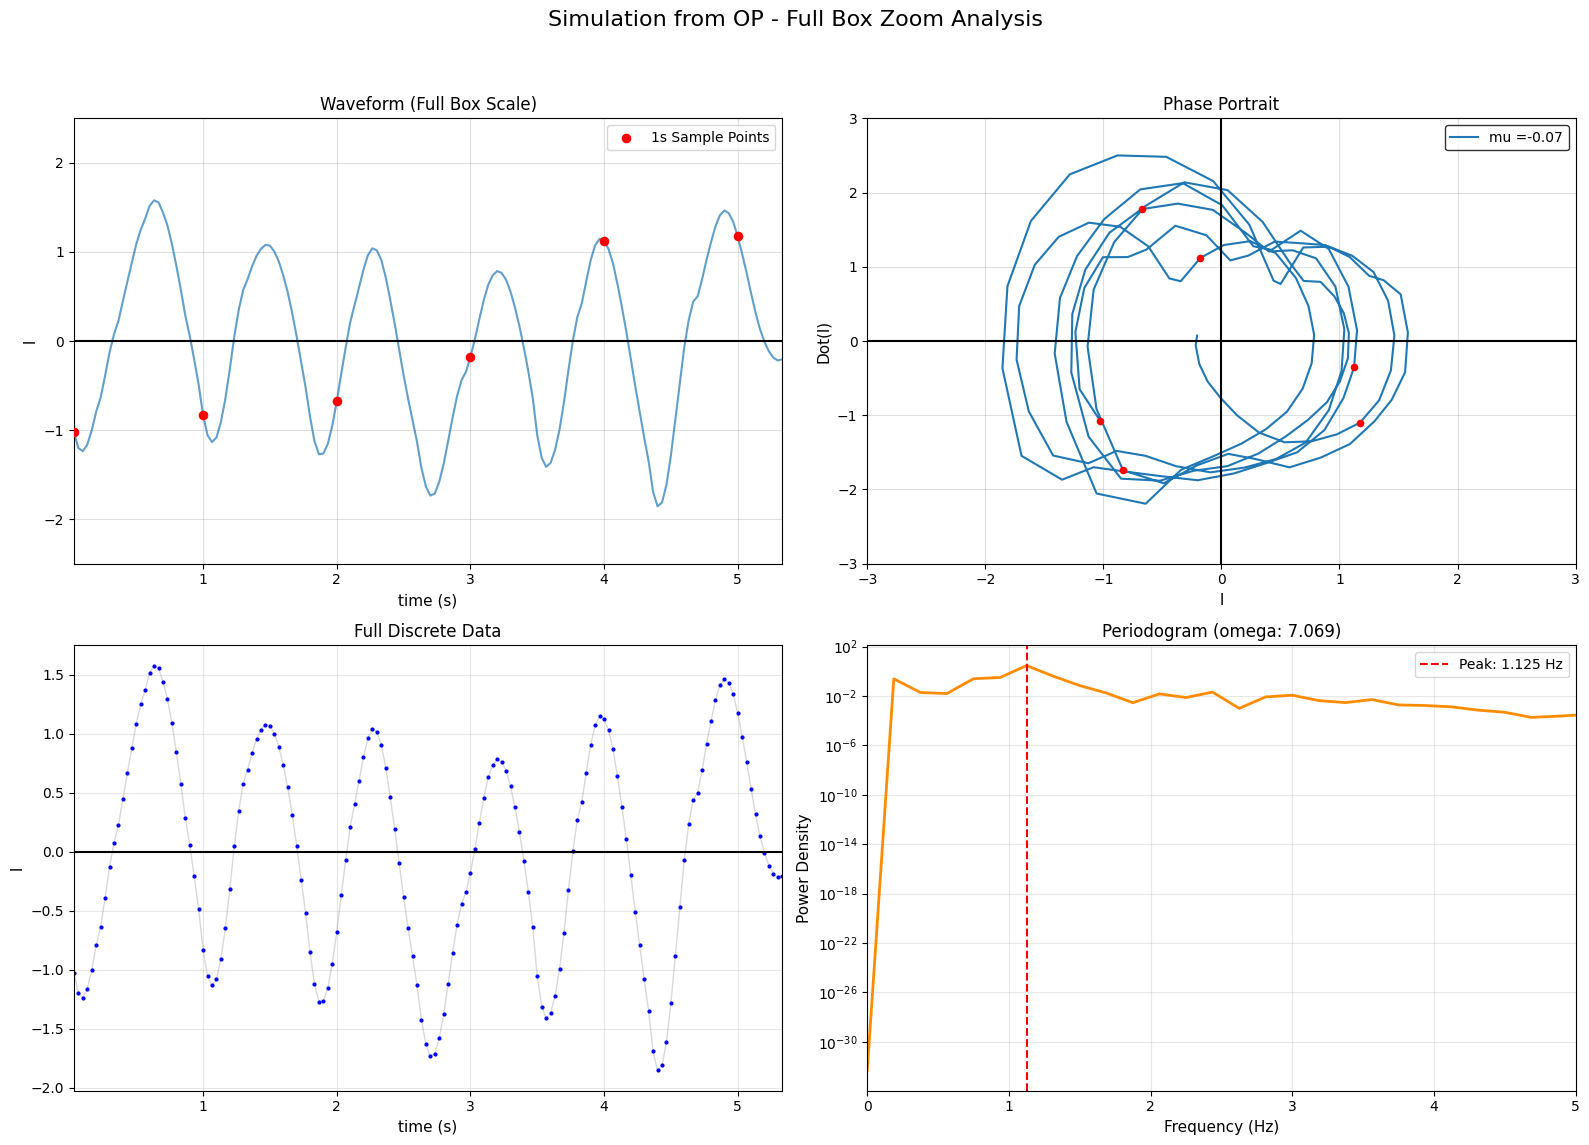

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from scipy import signal
from google.colab import files
import os

# 1. KONFIGURASI VIDEO & DATA
video_path = 'balonaja.mp4'
output_video = 'analisis_vanderpol_full_zoom.mp4'

if not os.path.exists(video_path):
    print(f"Error: File {video_path} tidak ditemukan!")
else:
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*'MP4V')
    out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

    list_x, time_steps = [], []
    blueLower, blueUpper = (90, 70, 50), (130, 255, 255)

    while True:
        ret, frame = cap.read()
        if not ret: break

        hsv = cv2.cvtColor(cv2.GaussianBlur(frame, (11, 11), 0), cv2.COLOR_BGR2HSV)
        mask = cv2.dilate(cv2.erode(cv2.inRange(hsv, blueLower, blueUpper), None, iterations=3), None, iterations=3)
        cnts, _ = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(cnts) > 0:
            c = max(cnts, key=cv2.contourArea)
            if cv2.contourArea(c) > 500:
                M = cv2.moments(c)
                if M["m00"] != 0:
                    curr_x = M["m10"] / M["m00"]
                    list_x.append(curr_x)
                    time_steps.append(len(list_x) / fps)
                    cv2.circle(frame, (int(curr_x), int(M["m01"]/M["m00"])), 5, (0, 0, 255), -1)
        out.write(frame)

    cap.release()
    out.release()

    # --- 2. ANALISIS MATEMATIKA ---
    if len(list_x) > 15:
        x_norm = signal.detrend(list_x)
        x_norm = 2 * (x_norm / np.max(np.abs(x_norm)))

        x_smooth = signal.savgol_filter(x_norm, 11, 3)
        dt = 1/fps
        v_smooth = np.gradient(x_smooth, dt)
        v_norm = 2.5 * (v_smooth / np.max(np.abs(v_smooth)))

        # Sampling 1 Detik
        time_steps = np.array(time_steps)
        indices_1s = [np.abs(time_steps - t).argmin() for t in np.arange(0, time_steps[-1], 1.0)]
        t_1s = time_steps[indices_1s]
        x_1s = x_smooth[indices_1s]

        # Analisis Frekuensi & Mu
        freqs, psd = signal.periodogram(x_smooth, fps)
        f_peak = freqs[np.argmax(psd)]
        omega = 2 * np.pi * f_peak
        mu_est = (np.max(np.abs(v_smooth)) / (np.max(np.abs(x_smooth)) * omega)) - 1

        # --- 3. PLOTTING EMPAT PANEL (FULL ZOOM) ---
        plt.style.use('default')
        fig = plt.figure(figsize=(16, 12))
        gs = fig.add_gridspec(2, 2)
        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1])
        ax3 = fig.add_subplot(gs[1, 0])
        ax4 = fig.add_subplot(gs[1, 1])

        fig.suptitle('Simulation from OP - Full Box Zoom Analysis', fontsize=16)

        # Plot 1: Waveform (ZOOM FULL SATU KOTAK)
        ax1.plot(time_steps, x_smooth, color='#1f77b4', lw=1.5, alpha=0.7)
        ax1.scatter(t_1s, x_1s, color='red', s=35, label='1s Sample Points', zorder=3)
        ax1.set_xlabel('time (s)', fontsize=11)
        ax1.set_ylabel('l', fontsize=11)
        # Zoom otomatis agar memenuhi kotak:
        ax1.set_xlim(time_steps[0], time_steps[-1])
        ax1.set_ylim(-2.5, 2.5)
        ax1.axhline(0, color='black', lw=1.5)
        ax1.grid(True, linestyle='-', alpha=0.4)
        ax1.set_title("Waveform (Full Box Scale)")
        ax1.legend(loc='upper right')

        # Plot 2: Phase Portrait (Mimic Referensi)
        ax2.plot(x_smooth, v_norm, color='#1f77b4', lw=1.5, label=f'mu ={mu_est:.2f}')
        ax2.scatter(x_smooth[indices_1s], v_norm[indices_1s], color='red', s=20, zorder=3)
        ax2.set_xlabel('l', fontsize=11)
        ax2.set_ylabel('Dot(l)', fontsize=11)
        ax2.set_xlim(-3, 3)
        ax2.set_ylim(-3, 3)
        ax2.axhline(0, color='black', lw=1.5)
        ax2.axvline(0, color='black', lw=1.5)
        ax2.grid(True, linestyle='-', alpha=0.4)
        ax2.legend(loc='upper right', edgecolor='black')
        ax2.set_title("Phase Portrait")

        # Plot 3: Full Discrete x(t)
        ax3.plot(time_steps, x_smooth, color='gray', lw=1, alpha=0.3)
        ax3.plot(time_steps, x_smooth, 'bo', markersize=2, label='Full Discretized')
        ax3.set_xlabel('time (s)', fontsize=11)
        ax3.set_ylabel('l', fontsize=11)
        ax3.set_xlim(time_steps[0], time_steps[-1])
        ax3.axhline(0, color='black', lw=1.5)
        ax3.grid(True, alpha=0.3)
        ax3.set_title("Full Discrete Data")

        # Plot 4: Periodogram
        ax4.semilogy(freqs, psd, color='darkorange', lw=2)
        ax4.axvline(f_peak, color='red', linestyle='--', label=f'Peak: {f_peak:.3f} Hz')
        ax4.set_xlabel('Frequency (Hz)', fontsize=11)
        ax4.set_ylabel('Power Density', fontsize=11)
        ax4.set_xlim(0, 5)
        ax4.grid(True, which="both", alpha=0.3)
        ax4.legend()
        ax4.set_title(f"Periodogram (omega: {omega:.3f})")

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    files.download(output_video)

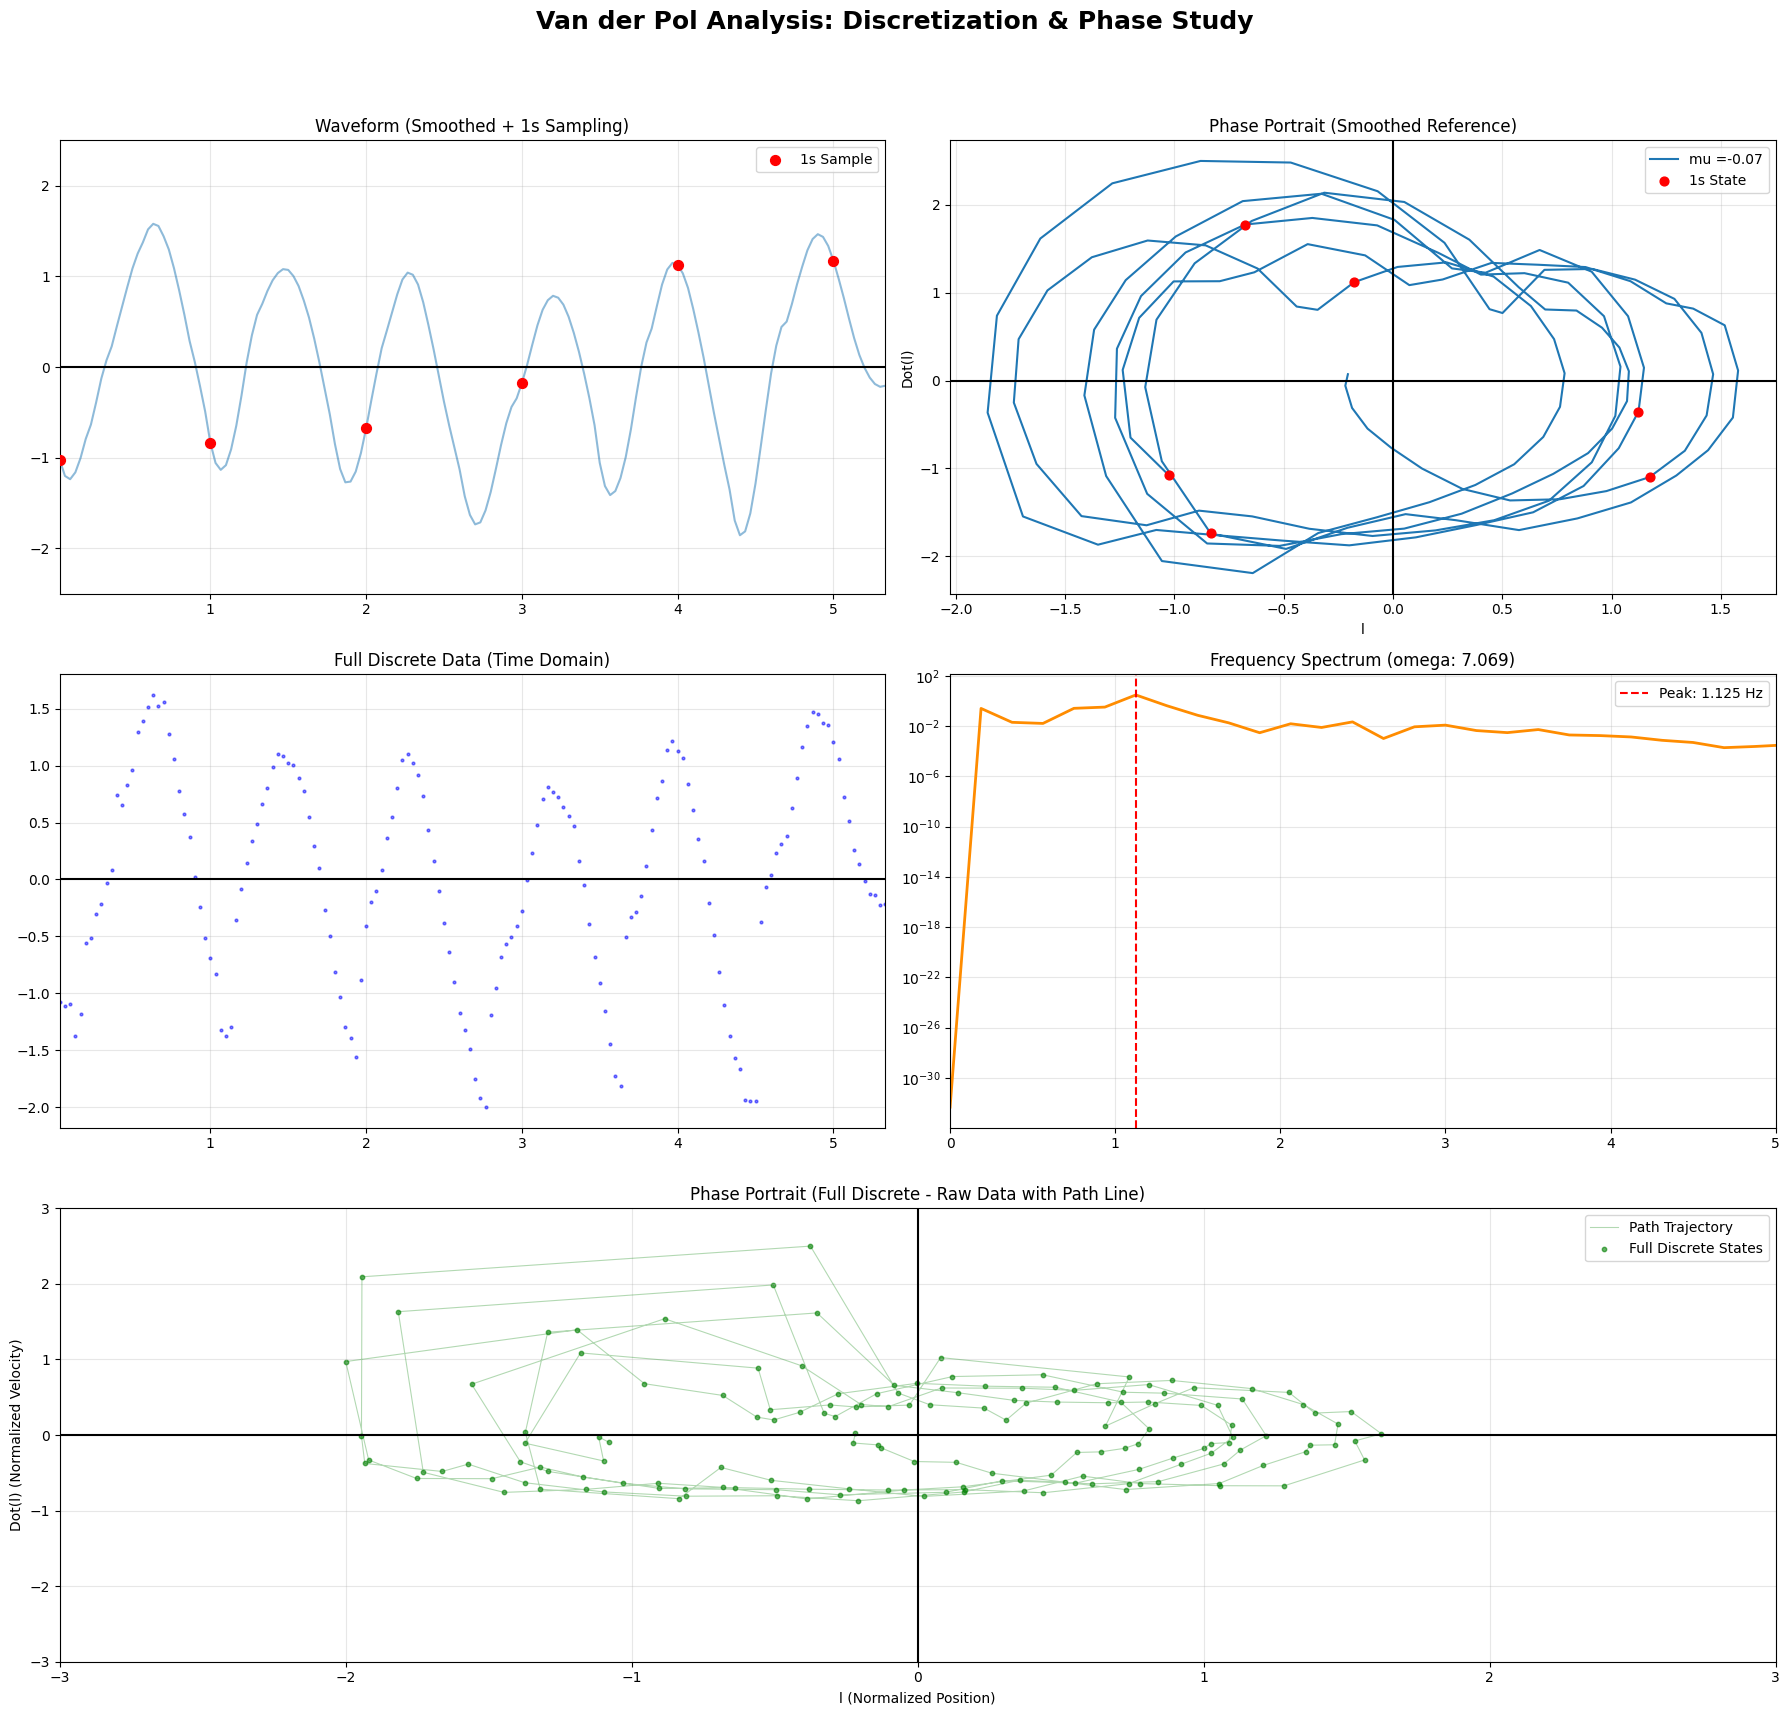

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from scipy import signal
from google.colab import files
import os

# 1. KONFIGURASI VIDEO & DATA
video_path = 'balonaja.mp4'
output_video = 'analisis_vanderpol_final_5plot.mp4'

if not os.path.exists(video_path):
    print(f"Error: File {video_path} tidak ditemukan!")
else:
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*'MP4V')
    out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

    list_x, time_steps = [], []
    blueLower, blueUpper = (90, 70, 50), (130, 255, 255)

    while True:
        ret, frame = cap.read()
        if not ret: break

        hsv = cv2.cvtColor(cv2.GaussianBlur(frame, (11, 11), 0), cv2.COLOR_BGR2HSV)
        mask = cv2.dilate(cv2.erode(cv2.inRange(hsv, blueLower, blueUpper), None, iterations=3), None, iterations=3)
        cnts, _ = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(cnts) > 0:
            c = max(cnts, key=cv2.contourArea)
            if cv2.contourArea(c) > 500:
                M = cv2.moments(c)
                if M["m00"] != 0:
                    curr_x = M["m10"] / M["m00"]
                    list_x.append(curr_x)
                    time_steps.append(len(list_x) / fps)
                    cv2.circle(frame, (int(curr_x), int(M["m01"]/M["m00"])), 5, (0, 0, 255), -1)
        out.write(frame)

    cap.release()
    out.release()

    # --- 2. ANALISIS MATEMATIKA ---
    if len(list_x) > 15:
        # Data Detrended (Data Mentah)
        x_detrend = signal.detrend(list_x)
        x_raw_norm = 2 * (x_detrend / np.max(np.abs(x_detrend)))
        dt = 1/fps
        v_raw = np.gradient(x_raw_norm, dt)
        v_raw_norm = 2.5 * (v_raw / np.max(np.abs(v_raw)))

        # Data Smoothed
        x_smooth = signal.savgol_filter(x_raw_norm, 11, 3)
        v_smooth = np.gradient(x_smooth, dt)
        v_smooth_norm = 2.5 * (v_smooth / np.max(np.abs(v_smooth)))

        # Sampling 1 Detik
        time_steps = np.array(time_steps)
        indices_1s = [np.abs(time_steps - t).argmin() for t in np.arange(0, time_steps[-1], 1.0)]
        t_1s = time_steps[indices_1s]
        x_1s = x_smooth[indices_1s]
        v_1s = v_smooth_norm[indices_1s]

        # Analisis Frekuensi
        freqs, psd = signal.periodogram(x_smooth, fps)
        f_peak = freqs[np.argmax(psd)]
        omega = 2 * np.pi * f_peak
        mu_est = (np.max(np.abs(v_smooth)) / (np.max(np.abs(x_smooth)) * omega)) - 1

        # --- 3. PLOTTING LIMA PANEL ---
        plt.style.use('default')
        fig = plt.figure(figsize=(18, 18))
        gs = fig.add_gridspec(3, 2)

        ax1 = fig.add_subplot(gs[0, 0]) # Waveform
        ax2 = fig.add_subplot(gs[0, 1]) # Phase Portrait Smooth + Sampling 1s
        ax3 = fig.add_subplot(gs[1, 0]) # Full Discrete Time
        ax4 = fig.add_subplot(gs[1, 1]) # Periodogram (Tukar ke sini)
        ax5 = fig.add_subplot(gs[2, :])    # Full Discrete Phase Portrait (Tukar ke bawah)

        fig.suptitle('Van der Pol Analysis: Discretization & Phase Study', fontsize=18, fontweight='bold')

        # G1: Waveform (Sampling 1s)
        ax1.plot(time_steps, x_smooth, color='#1f77b4', lw=1.5, alpha=0.5)
        ax1.scatter(t_1s, x_1s, color='red', s=50, label='1s Sample', zorder=3)
        ax1.set_title("Waveform (Smoothed + 1s Sampling)")
        ax1.set_xlim(time_steps[0], time_steps[-1]); ax1.set_ylim(-2.5, 2.5)
        ax1.axhline(0, color='black', lw=1.5); ax1.grid(True, alpha=0.3); ax1.legend()

        # G2: Phase Portrait (Smooth + Dot Sampling 1s)
        ax2.plot(x_smooth, v_smooth_norm, color='#1f77b4', lw=1.5, label=f'mu ={mu_est:.2f}')
        ax2.scatter(x_1s, v_1s, color='red', s=40, zorder=3, label='1s State') # Penanda 1s tidak hilang
        ax2.set_title("Phase Portrait (Smoothed Reference)")
        ax2.set_xlabel('l'); ax2.set_ylabel('Dot(l)')
        ax2.axhline(0, color='black', lw=1.5); ax2.axvline(0, color='black', lw=1.5)
        ax2.grid(True, alpha=0.3); ax2.legend()

        # G3: Full Discrete Data x(t)
        ax3.plot(time_steps, x_raw_norm, 'bo', markersize=2, alpha=0.5, label='Raw Frames')
        ax3.set_title("Full Discrete Data (Time Domain)")
        ax3.set_xlim(time_steps[0], time_steps[-1]); ax3.axhline(0, color='black', lw=1.5)
        ax3.grid(True, alpha=0.3)

        # G4: Periodogram (Position Swapped)
        ax4.semilogy(freqs, psd, color='darkorange', lw=2)
        ax4.axvline(f_peak, color='red', linestyle='--', label=f'Peak: {f_peak:.3f} Hz')
        ax4.set_title(f"Frequency Spectrum (omega: {omega:.3f})")
        ax4.set_xlim(0, 5); ax4.grid(True, which="both", alpha=0.3); ax4.legend()

        # G5: Phase Portrait (FULL DISCRETE - Position Swapped & Enhanced)
        # Menambahkan line penghubung agar alur diskritisasi per frame terlihat
        ax5.plot(x_raw_norm, v_raw_norm, color='green', lw=0.8, alpha=0.3, label='Path Trajectory')
        ax5.scatter(x_raw_norm, v_raw_norm, color='green', s=10, alpha=0.6, label='Full Discrete States')
        ax5.set_title("Phase Portrait (Full Discrete - Raw Data with Path Line)")
        ax5.set_xlabel('l (Normalized Position)'); ax5.set_ylabel('Dot(l) (Normalized Velocity)')
        ax5.set_xlim(-3, 3); ax5.set_ylim(-3, 3)
        ax5.axhline(0, color='black', lw=1.5); ax5.axvline(0, color='black', lw=1.5)
        ax5.grid(True, alpha=0.3); ax5.legend(loc='upper right')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    files.download(output_video)

Memproses Video...


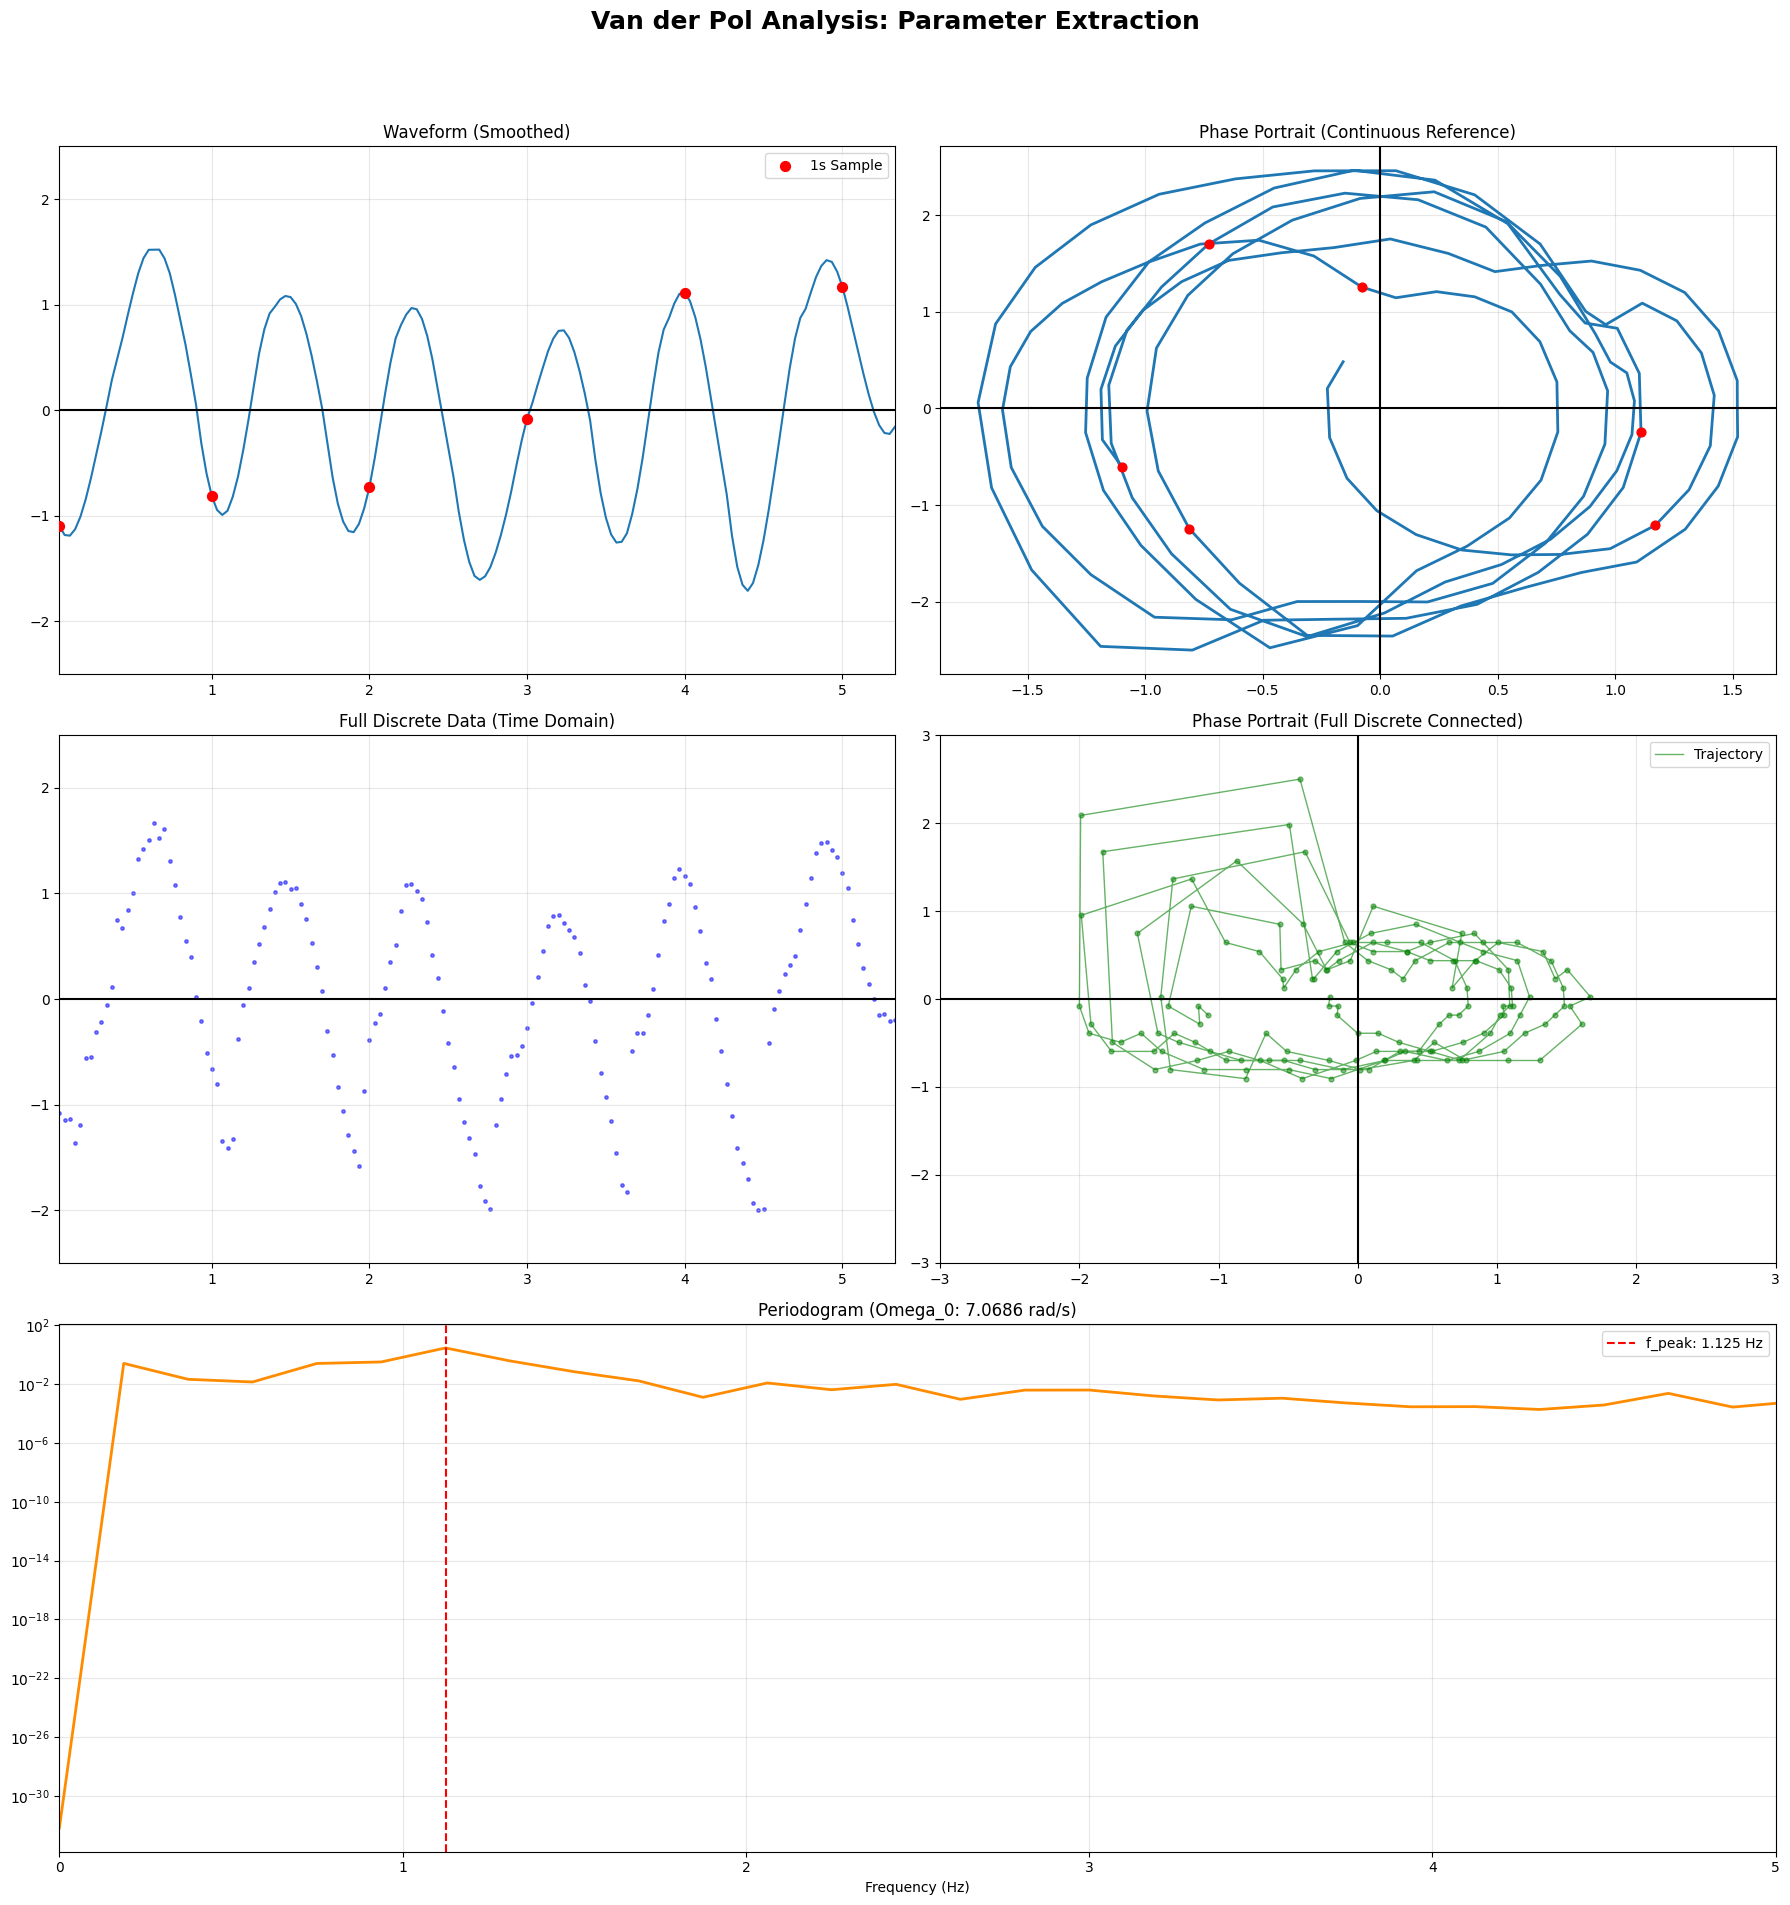


         HASIL EKSTRAKSI PARAMETER
1. Simpangan rata-rata (ξ) : 0.7838 unit
2. Durasi total (t)        : 5.33 s
3. Amplitudo (A)           : 1.7113
4. Frekuensi Sudut (ω_0)   : 7.0686 rad/s
5. Fase Awal (ϕ)           : 2.2677 rad
---------------------------------------------
MODEL PERSAMAAN ANALITIK:
ξ(t) = 1.71 * cos(7.07t + 2.27)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from google.colab import files
import os

# 1. KONFIGURASI VIDEO & DATA
video_path = 'balonaja.mp4'
output_video = 'analisis_vanderpol_final_lengkap.mp4'

if not os.path.exists(video_path):
    print(f"Error: File {video_path} tidak ditemukan!")
else:
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*'MP4V')
    out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

    list_x, time_steps = [], []
    blueLower, blueUpper = (90, 70, 50), (130, 255, 255)

    print("Memproses Video...")
    while True:
        ret, frame = cap.read()
        if not ret: break

        hsv = cv2.cvtColor(cv2.GaussianBlur(frame, (11, 11), 0), cv2.COLOR_BGR2HSV)
        mask = cv2.dilate(cv2.erode(cv2.inRange(hsv, blueLower, blueUpper), None, iterations=3), None, iterations=3)
        cnts, _ = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(cnts) > 0:
            c = max(cnts, key=cv2.contourArea)
            if cv2.contourArea(c) > 500:
                M = cv2.moments(c)
                if M["m00"] != 0:
                    curr_x = int(M["m10"] / M["m00"])
                    curr_y = int(M["m01"] / M["m00"])
                    list_x.append(curr_x)
                    time_steps.append(len(list_x) / fps)

                    cv2.circle(frame, (curr_x, curr_y), 20, (0, 255, 255), 2)
                    cv2.circle(frame, (curr_x, curr_y), 5, (0, 0, 255), -1)
                    cv2.putText(frame, f"({curr_x}, {curr_y})", (curr_x + 25, curr_y),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        out.write(frame)

    cap.release()
    out.release()

    # --- 2. ANALISIS MATEMATIKA ---
    if len(list_x) > 15:
        x_raw = signal.detrend(list_x)
        x_raw_norm = 2 * (x_raw / np.max(np.abs(x_raw)))
        dt = 1/fps
        v_raw_norm = np.gradient(x_raw_norm, dt)
        v_raw_norm = 2.5 * (v_raw_norm / np.max(np.abs(v_raw_norm)))

        x_smooth = signal.savgol_filter(x_raw_norm, 15, 3)
        v_smooth_norm = 2.5 * (np.gradient(x_smooth, dt) / np.max(np.abs(np.gradient(x_smooth, dt))))

        time_steps = np.array(time_steps)
        indices_1s = [np.abs(time_steps - t).argmin() for t in np.arange(0, time_steps[-1], 1.0)]
        t_1s, x_1s, v_1s = time_steps[indices_1s], x_smooth[indices_1s], v_smooth_norm[indices_1s]

        # Parameter Pendekatan xi(t) = A cos(omega_0 * t + phi)
        freqs, psd = signal.periodogram(x_smooth, fps)
        f_peak = freqs[np.argmax(psd)]
        omega_0 = 2 * np.pi * f_peak
        A_val = np.max(np.abs(x_smooth))
        phi_val = np.arccos(np.clip(x_smooth[0]/A_val, -1, 1))
        t_total = time_steps[-1]

        # --- 3. PLOTTING 5 PANEL ---
        plt.style.use('default')
        fig = plt.figure(figsize=(18, 20))
        gs = fig.add_gridspec(3, 2)

        ax1 = fig.add_subplot(gs[0, 0]); ax2 = fig.add_subplot(gs[0, 1])
        ax3 = fig.add_subplot(gs[1, 0]); ax4 = fig.add_subplot(gs[1, 1])
        ax5 = fig.add_subplot(gs[2, :])

        fig.suptitle('Van der Pol Analysis: Parameter Extraction', fontsize=18, fontweight='bold')

        # G1: Waveform
        ax1.plot(time_steps, x_smooth, color='#1f77b4', lw=1.5)
        ax1.scatter(t_1s, x_1s, color='red', s=50, label='1s Sample', zorder=3)
        ax1.set_title("Waveform (Smoothed)")
        ax1.set_xlim(time_steps[0], t_total); ax1.set_ylim(-2.5, 2.5)
        ax1.axhline(0, color='black', lw=1.5); ax1.grid(True, alpha=0.3); ax1.legend()

        # G2: Phase Portrait Smooth
        ax2.plot(x_smooth, v_smooth_norm, color='#1f77b4', lw=2)
        ax2.scatter(x_1s, v_1s, color='red', s=40, zorder=3)
        ax2.set_title("Phase Portrait (Continuous Reference)")
        ax2.axhline(0, color='black', lw=1.5); ax2.axvline(0, color='black', lw=1.5)
        ax2.grid(True, alpha=0.3)

        # G3: Full Discrete Time Domain
        ax3.scatter(time_steps, x_raw_norm, color='blue', s=6, alpha=0.5)
        ax3.set_title("Full Discrete Data (Time Domain)")
        ax3.set_xlim(time_steps[0], t_total); ax3.set_ylim(-2.5, 2.5)
        ax3.axhline(0, color='black', lw=1.5); ax3.grid(True, alpha=0.3)

        # G4: Phase Portrait Full Diskret (Connected Path)
        ax4.plot(x_raw_norm, v_raw_norm, color='green', lw=1, alpha=0.6, label='Trajectory')
        ax4.scatter(x_raw_norm, v_raw_norm, color='green', s=12, alpha=0.5)
        ax4.set_title("Phase Portrait (Full Discrete Connected)")
        ax4.set_xlim(-3, 3); ax4.set_ylim(-3, 3)
        ax4.axhline(0, color='black', lw=1.5); ax4.axvline(0, color='black', lw=1.5)
        ax4.grid(True, alpha=0.3); ax4.legend()

        # G5: Periodogram
        ax5.semilogy(freqs, psd, color='darkorange', lw=2)
        ax5.axvline(f_peak, color='red', linestyle='--', label=f'f_peak: {f_peak:.3f} Hz')
        ax5.set_title(f"Periodogram (Omega_0: {omega_0:.4f} rad/s)")
        ax5.set_xlabel("Frequency (Hz)"); ax5.set_xlim(0, 5)
        ax5.grid(True, which="both", alpha=0.3); ax5.legend()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

        # --- 4. OUTPUT NILAI PARAMETER TERPERINCI ---
        print("\n" + "="*45)
        print("         HASIL EKSTRAKSI PARAMETER")
        print("="*45)
        print(f"1. Simpangan rata-rata (ξ) : {np.mean(np.abs(x_smooth)):.4f} unit")
        print(f"2. Durasi total (t)        : {t_total:.2f} s")
        print(f"3. Amplitudo (A)           : {A_val:.4f}")
        print(f"4. Frekuensi Sudut (ω_0)   : {omega_0:.4f} rad/s")
        print(f"5. Fase Awal (ϕ)           : {phi_val:.4f} rad")
        print("-"*45)
        print(f"MODEL PERSAMAAN ANALITIK:")
        print(f"ξ(t) = {A_val:.2f} * cos({omega_0:.2f}t + {phi_val:.2f})")
        print("="*45)

    files.download(output_video)


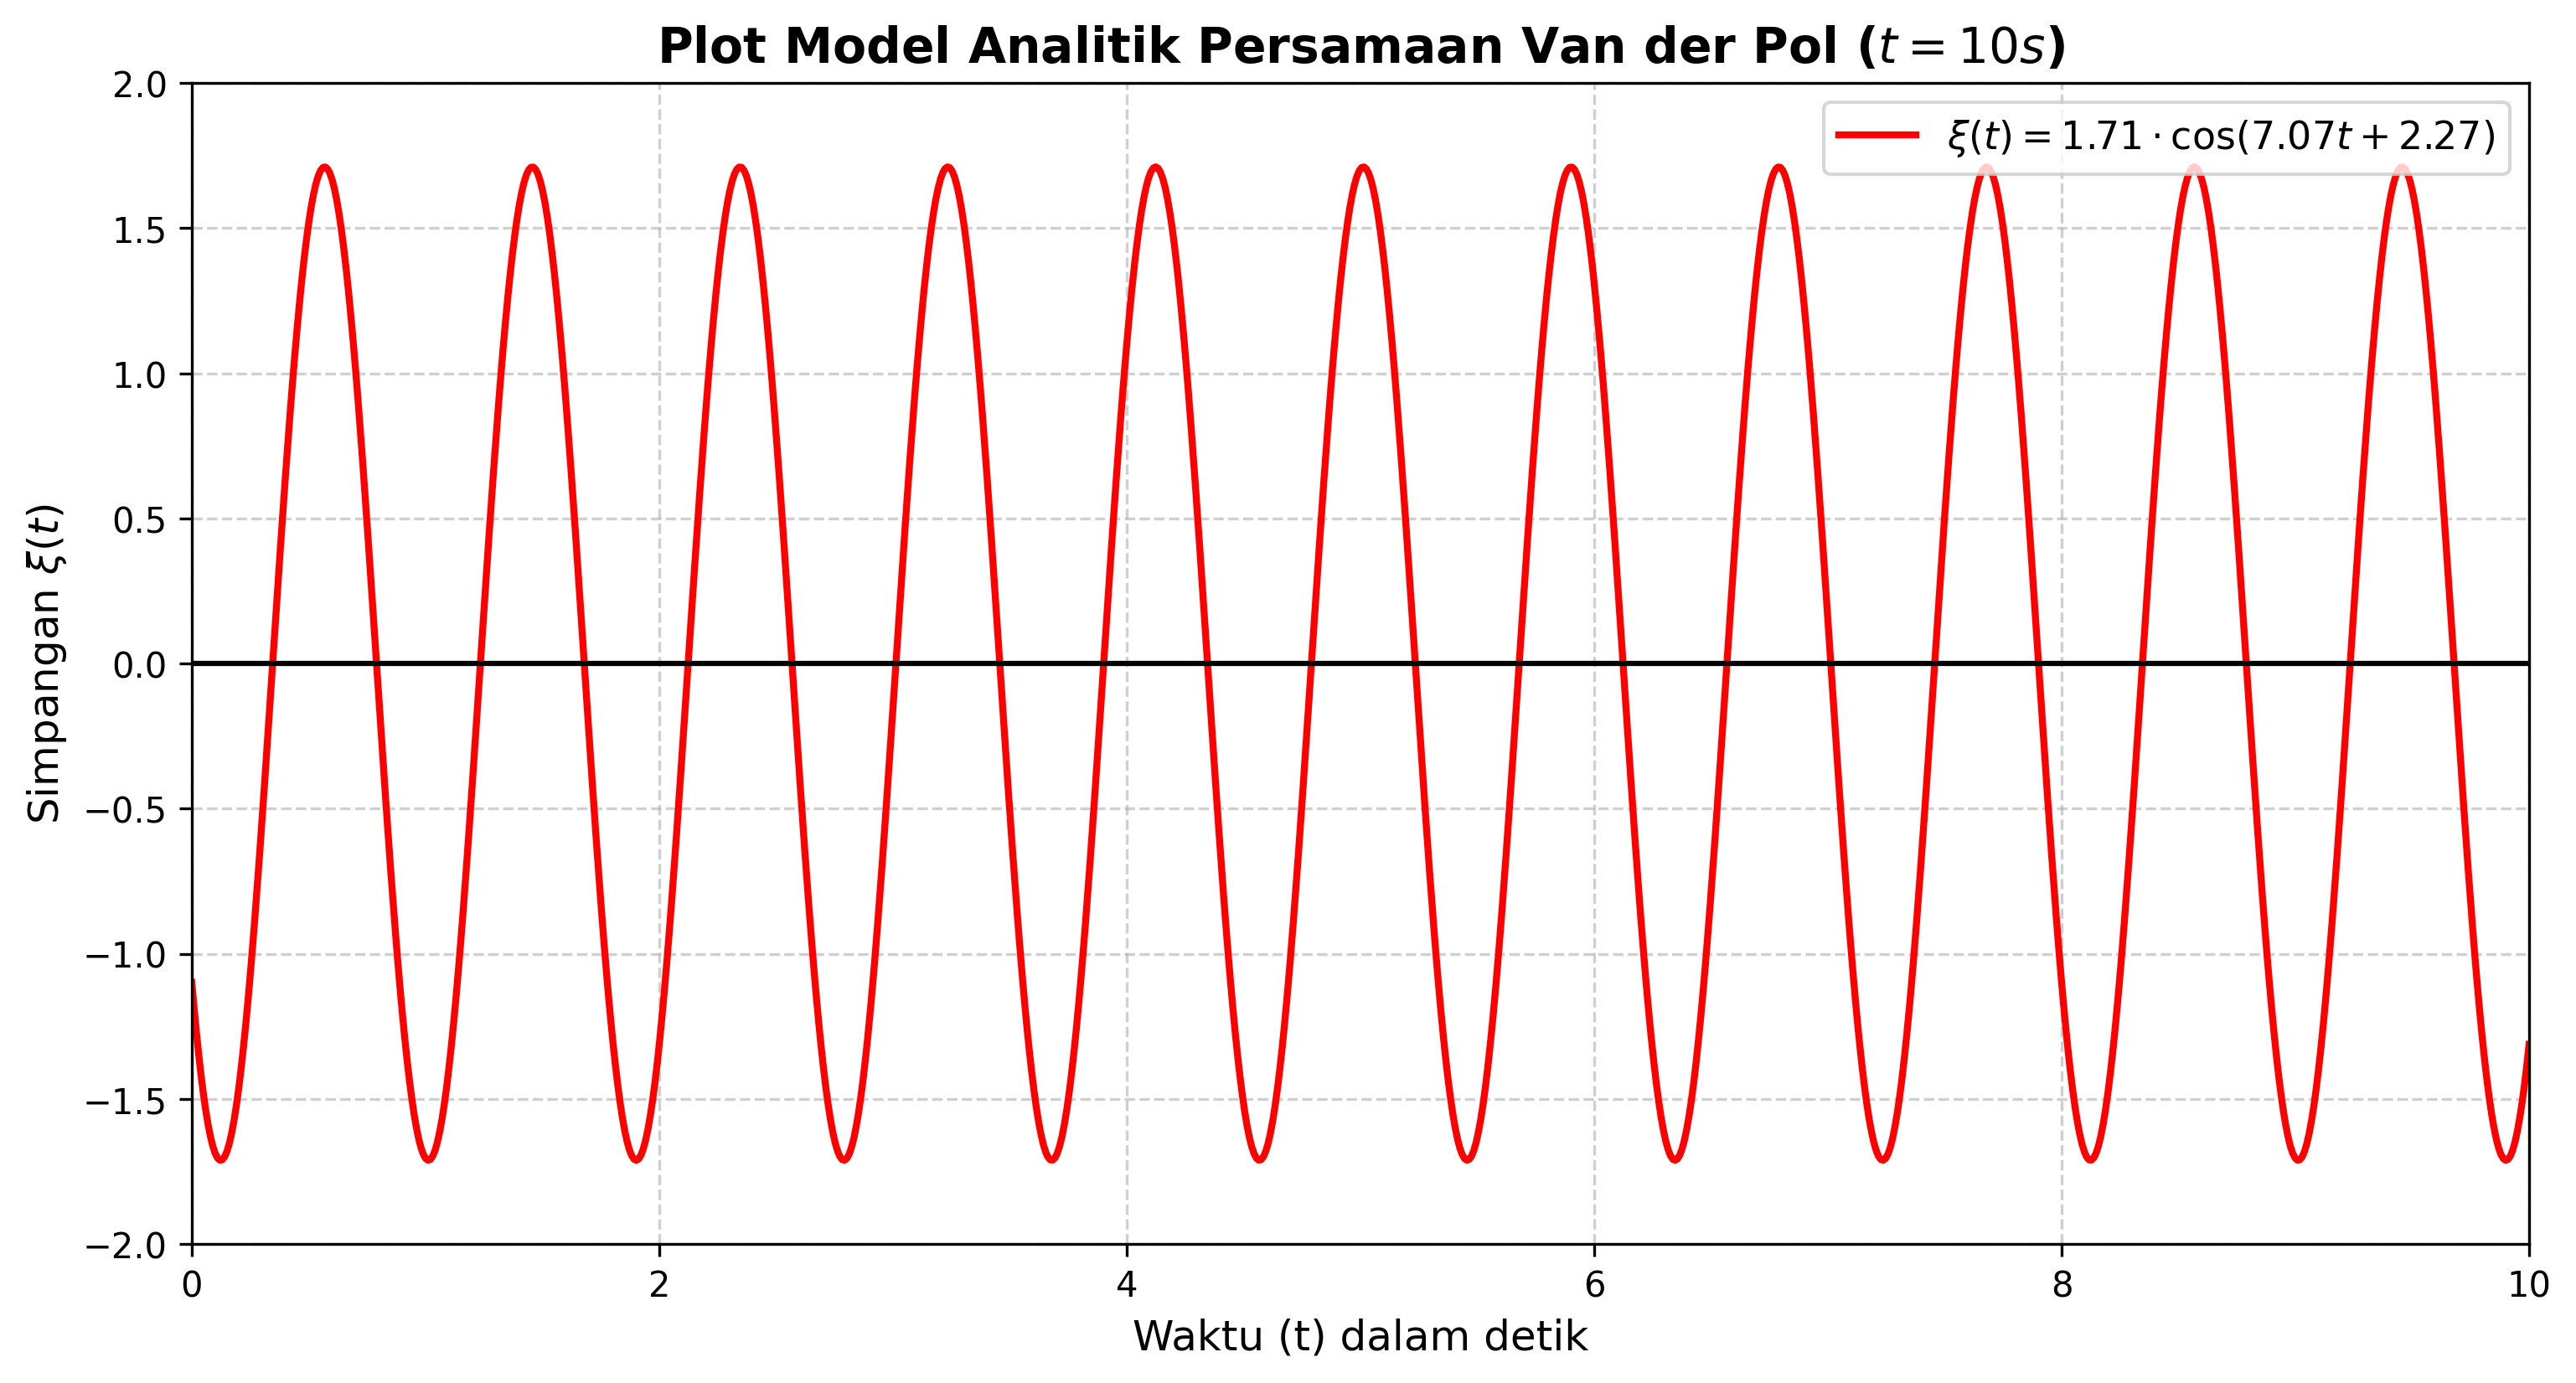

Informasi Grafik:
- Frekuensi: 1.125 Hz
- Jumlah Osilasi dalam 10s: 11.3 siklus


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# 1. DEFINISI PARAMETER (Sesuai Hasil Ekstraksi Anda)
A = 1.7113        # Amplitudo
omega_0 = 7.0686  # Frekuensi Sudut (rad/s)
phi = 2.2677      # Fase Awal (rad)
t_max = 10        # Durasi yang diinginkan (s)

# 2. GENERASI DATA
# Menggunakan 1000 titik agar grafik terlihat sangat halus (HD)
t = np.linspace(0, t_max, 1000)
xi_t = A * np.cos(omega_0 * t + phi)

# 3. PLOTTING
plt.figure(figsize=(12, 6), dpi=300) # Resolusi Tinggi
plt.plot(t, xi_t, color='red', lw=2, label=r'$\xi(t) = 1.71 \cdot \cos(7.07t + 2.27)$')

# Dekorasi Grafik
plt.title("Plot Model Analitik Persamaan Van der Pol ($t=10s$)", fontsize=14, fontweight='bold')
plt.xlabel("Waktu (t) dalam detik", fontsize=12)
plt.ylabel("Simpangan $\\xi(t)$", fontsize=12)
plt.axhline(0, color='black', lw=1.5) # Garis setimbang
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, t_max)
plt.ylim(-2, 2)
plt.legend(loc='upper right', fontsize=11)

# Simpan dan Download
filename = "Plot_Analitik_VanderPol_10s.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

# Jika di Google Colab, aktifkan ini untuk download otomatis:
# files.download(filename)

# 4. INFORMASI TAMBAHAN
freq_hz = omega_0 / (2 * np.pi)
print(f"Informasi Grafik:")
print(f"- Frekuensi: {freq_hz:.3f} Hz")
print(f"- Jumlah Osilasi dalam 10s: {freq_hz * t_max:.1f} siklus")

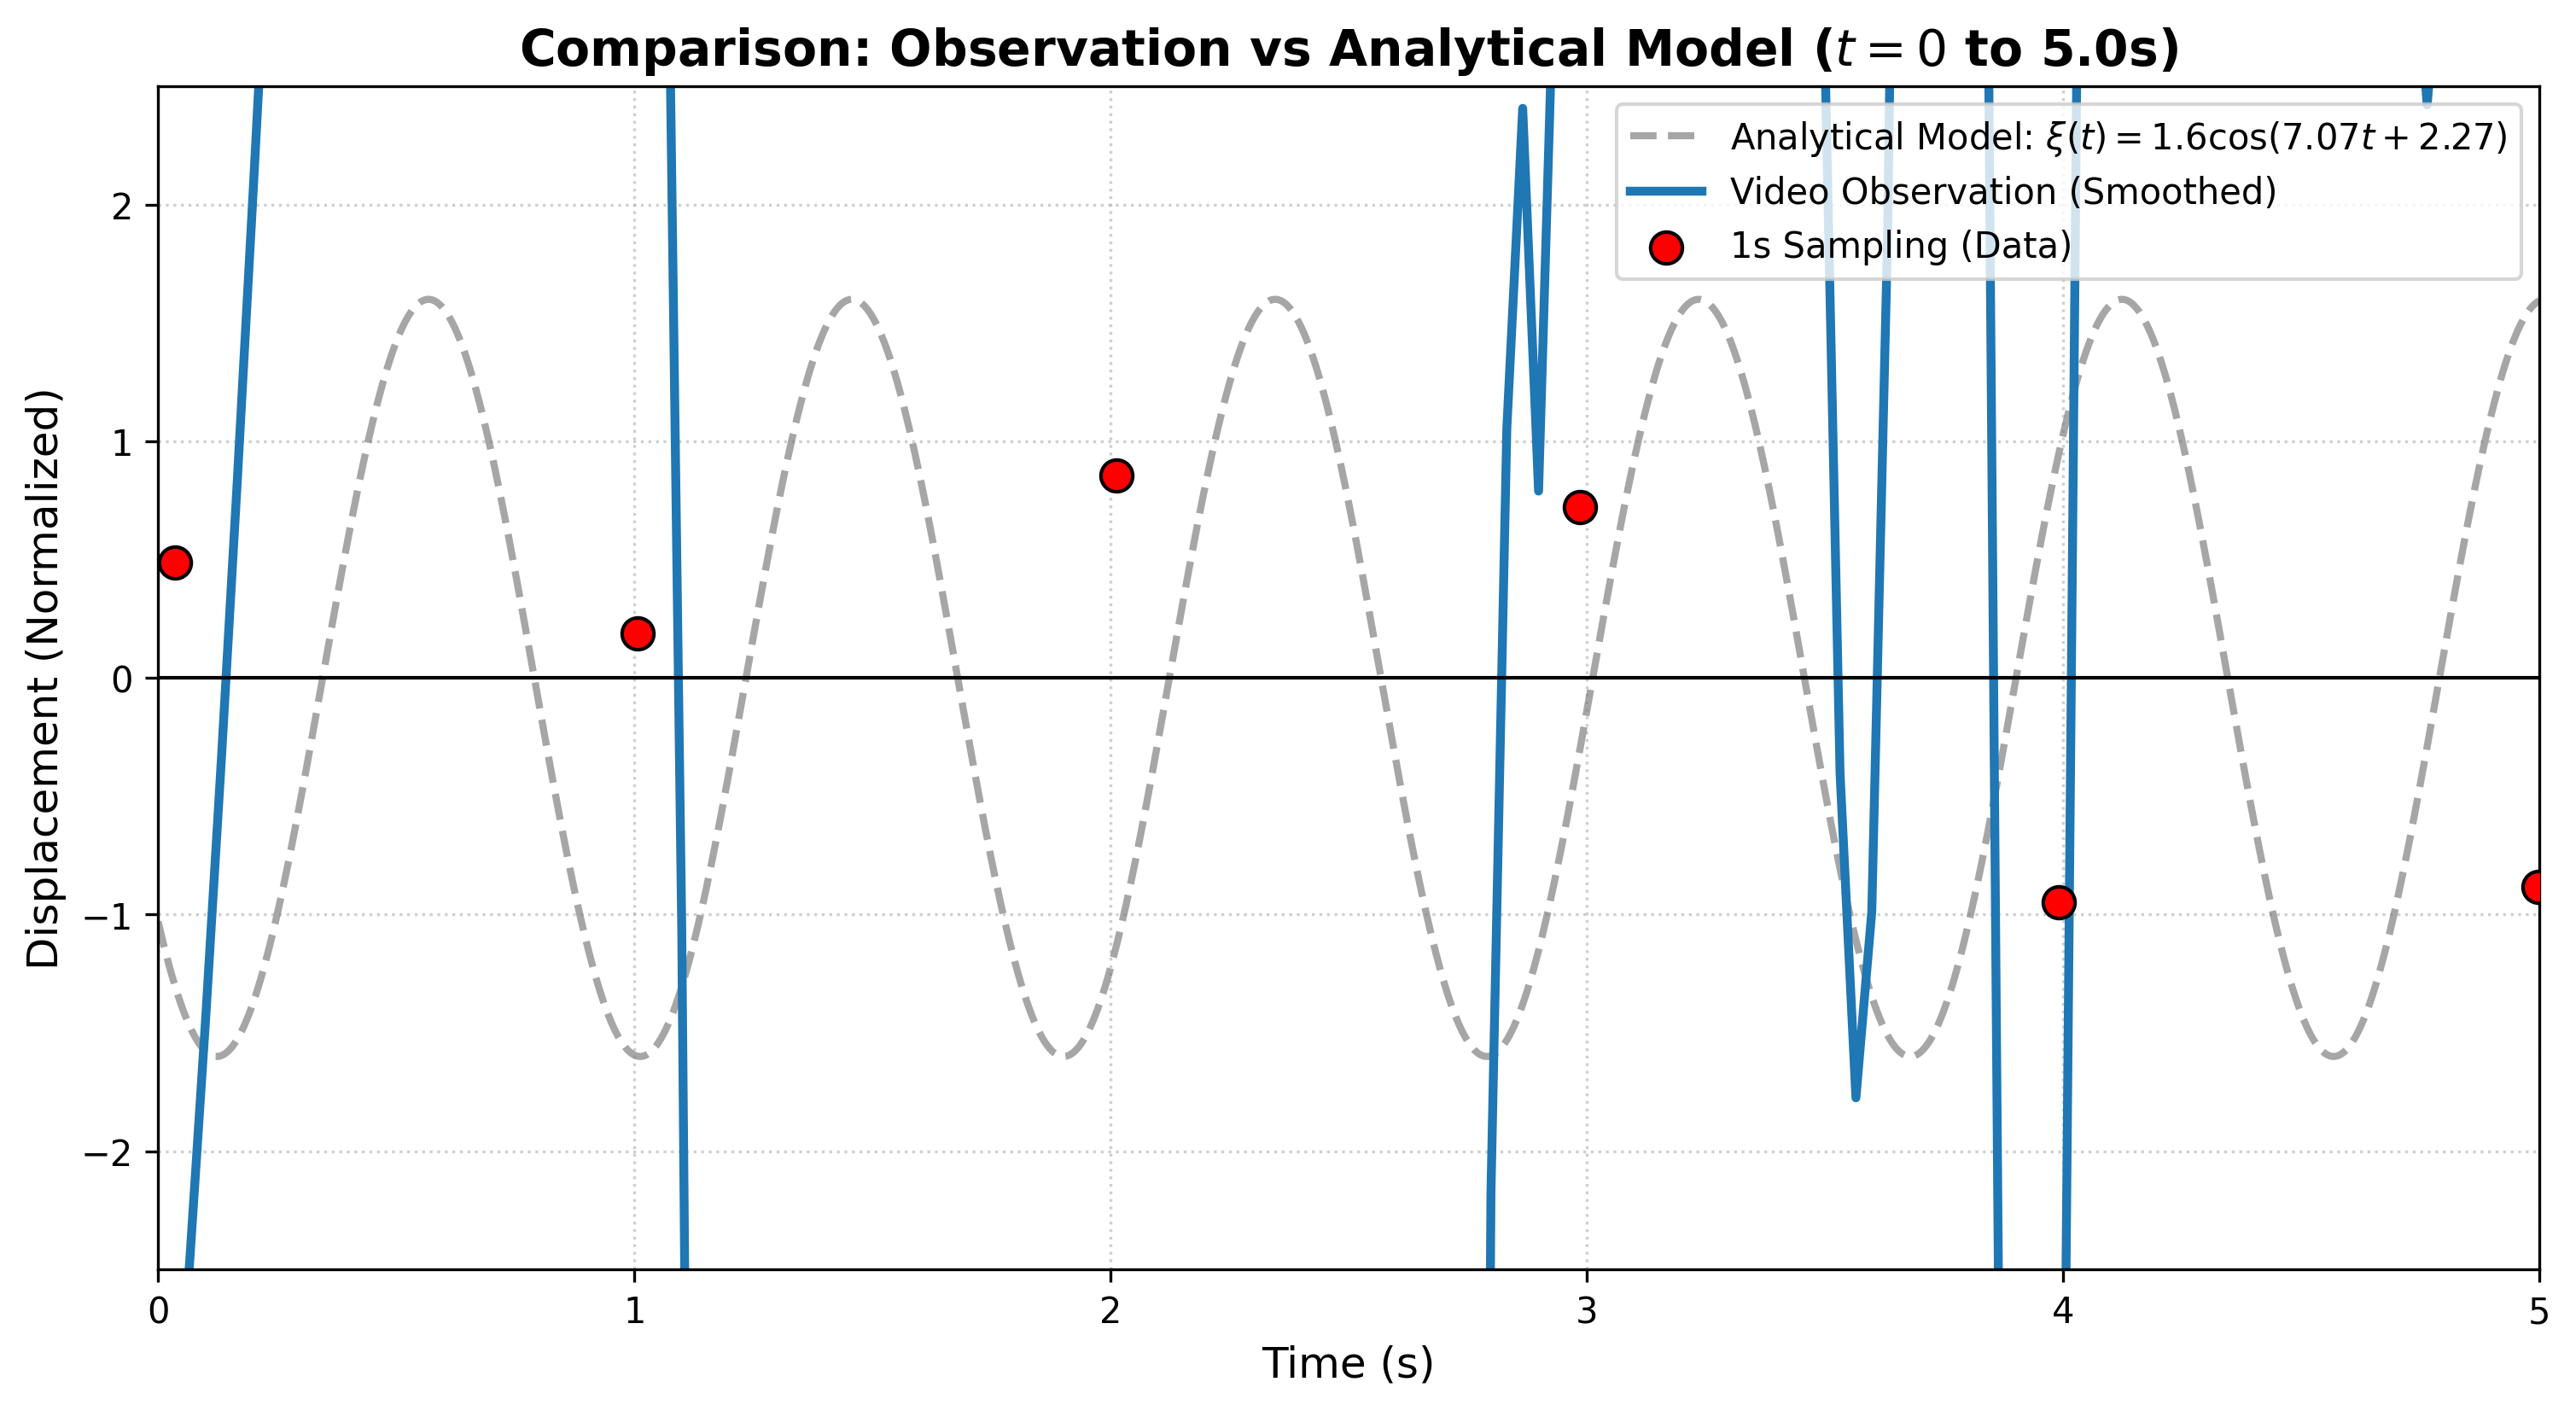

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from google.colab import files

# --- 1. PARAMETER ANALITIK (Berdasarkan Koreksi Anda) ---
A = 1.6
omega_0 = 7.0686
phi = 2.27
t_limit = 5.0

# Membuat data resolusi tinggi untuk kurva teoritis
t_analytic = np.linspace(0, t_limit, 1000)
xi_analytic = A * np.cos(omega_0 * t_analytic + phi)

# --- 2. PLOTTING PERBANDINGAN HD ---
plt.figure(figsize=(12, 6), dpi=300) # Kualitas HD 300 DPI

# A. Plot Model Analitik (Garis Putus-putus Abu-abu)
plt.plot(t_analytic, xi_analytic, color='gray', linestyle='--', lw=2, alpha=0.7,
         label=r'Analytical Model: $\xi(t) = 1.6 \cos(7.07t + 2.27)$')

# B. Plot Data Observasi Video (Mengambil variabel dari proses sebelumnya)
try:
    # Filter data video hingga limit 5 detik
    mask = time_steps <= t_limit
    plt.plot(time_steps[mask], x_smooth[mask], color='#1f77b4', lw=2.5,
             label='Video Observation (Smoothed)')

    # Tambahkan titik sampling per 1 detik (Titik Merah)
    t_1s_mask = (t_1s <= t_limit)
    plt.scatter(t_1s[t_1s_mask], x_1s[t_1s_mask], color='red', s=80,
                edgecolors='black', label='1s Sampling (Data)', zorder=5)
except NameError:
    print("Error: Variabel data video tidak ditemukan.")
    print("Pastikan Anda menjalankan blok kode tracking video terlebih dahulu.")

# C. Styling Grafik
plt.title(f"Comparison: Observation vs Analytical Model ($t = 0$ to {t_limit}s)",
          fontsize=14, fontweight='bold')
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Displacement (Normalized)", fontsize=12)
plt.axhline(0, color='black', lw=1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0, t_limit)
plt.ylim(-2.5, 2.5)
plt.legend(loc='upper right', frameon=True, fontsize=10)

# Simpan dan Tampilkan
filename = "Comparison_Model_vs_Obs_HD.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

# Download file hasil secara otomatis
files.download(filename)

In [ ]:
import cv2
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from scipy import signal
from google.colab import files
import os

# 1. KONFIGURASI VIDEO & DATA
video_path = 'balonvanderpol2.mp4'
output_video = 'analisis_vanderpol_tracking.mp4'

if not os.path.exists(video_path):
    print(f"Error: File {video_path} tidak ditemukan!")
else:
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    list_x, time_steps = [], []
    blueLower, blueUpper = (90, 70, 50), (130, 255, 255)

    print("Memproses Video...")
    while True:
        ret, frame = cap.read()
        if not ret: break

        hsv = cv2.cvtColor(cv2.GaussianBlur(frame, (11, 11), 0), cv2.COLOR_BGR2HSV)
        mask = cv2.dilate(cv2.erode(cv2.inRange(hsv, blueLower, blueUpper), None, iterations=3), None, iterations=3)
        cnts, _ = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(cnts) > 0:
            c = max(cnts, key=cv2.contourArea)
            if cv2.contourArea(c) > 500:
                M = cv2.moments(c)
                if M["m00"] != 0:
                    curr_x = M["m10"] / M["m00"]
                    list_x.append(curr_x)
                    time_steps.append(len(list_x) / fps)
                    cv2.circle(frame, (int(curr_x), int(M["m01"]/M["m00"])), 5, (0, 0, 255), -1)
        out.write(frame)

    cap.release()
    out.release()

    # --- 2. ANALISIS MATEMATIKA ---
    if len(list_x) > 15:
        # Parameter Spesifik
        t_limit = 5.33
        f_peak_fix = 1.125
        f_mu_ref = 0.81
        mu_fix = 0.07
        omega_fix = 2 * np.pi * f_peak_fix

        time_steps = np.array(time_steps)
        mask_t = time_steps <= t_limit

        x_norm = signal.detrend(list_x)
        x_norm = 2 * (x_norm / np.max(np.abs(x_norm)))
        x_smooth = signal.savgol_filter(x_norm, 11, 3)
        dt = 1/fps
        v_smooth = np.gradient(x_smooth, dt)
        v_norm = 2.5 * (v_smooth / np.max(np.abs(v_smooth)))

        indices_1s = [np.abs(time_steps - t).argmin() for t in np.arange(0, t_limit + 0.1, 1.0)]
        t_1s, x_1s, v_1s = time_steps[indices_1s], x_smooth[indices_1s], v_norm[indices_1s]

        # --- 3. PLOTTING SINGLE HD IMAGE (3 IN 1) ---
        plt.style.use('default')
        # Membuat canvas besar (lebar 12, tinggi 18) untuk 3 plot vertikal
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 18), dpi=300)
        fig.suptitle('Van der Pol Analysis Summary (High Definition)', fontsize=20, fontweight='bold', y=0.98)

        # Plot 1: Waveform (5.33s)
        ax1.plot(time_steps[mask_t], x_smooth[mask_t], color='#1f77b4', lw=2, alpha=0.7)
        ax1.scatter(t_1s, x_1s, color='red', s=60, edgecolors='black', label='1s Sample Points', zorder=5)
        ax1.set_title("Waveform (Duration: 5.33s)", fontsize=15, fontweight='bold')
        ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Position X')
        ax1.set_xlim(0, t_limit); ax1.set_ylim(-2.5, 2.5)
        ax1.axhline(0, color='black', lw=1.5); ax1.grid(True, alpha=0.3); ax1.legend()

        # Plot 2: Phase Portrait (mu=0.07, ref 0.81Hz)
        ax2.plot(x_smooth[mask_t], v_norm[mask_t], color='#1f77b4', lw=2, label=f'mu = {mu_fix} (at {f_mu_ref} Hz)')
        ax2.scatter(x_1s, v_1s, color='red', s=50, edgecolors='black', zorder=5, label='1s State')
        ax2.set_title("Phase Portrait (Limit Cycle)", fontsize=15, fontweight='bold')
        ax2.set_xlabel('Position X'); ax2.set_ylabel('Dot(l) (Velocity)')
        ax2.set_xlim(-3, 3); ax2.set_ylim(-3, 3)
        ax2.axhline(0, color='black', lw=1.5); ax2.axvline(0, color='black', lw=1.5)
        ax2.grid(True, alpha=0.4); ax2.legend(loc='upper right')

        # Plot 3: Periodogram (1.125Hz)
        freqs, psd = signal.periodogram(x_smooth[mask_t], fps)
        ax3.semilogy(freqs, psd, color='darkorange', lw=2)
        ax3.axvline(f_peak_fix, color='red', linestyle='--', lw=2, label=f'Peak: {f_peak_fix} Hz')
        ax3.set_title(f"Periodogram (omega: {omega_fix:.3f} rad/s)", fontsize=15, fontweight='bold')
        ax3.set_xlabel("Frequency (Hz)"); ax3.set_ylabel("Power Density")
        ax3.set_xlim(0, 5); ax3.grid(True, which="both", alpha=0.3); ax3.legend()

        # Adjust layout agar tidak tumpang tindih
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])

        # Simpan sebagai satu file gambar
        combined_filename = 'VanderPol_Full_Analysis_HD.png'
        plt.savefig(combined_filename, dpi=300, bbox_inches='tight')
        plt.show()

        # Download file gambar tunggal
        files.download(combined_filename)
        print(f"Grafik tunggal '{combined_filename}' telah siap.")

Memproses Video...


NameError: name 'out' is not defined

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from google.colab import files
import os

# 1. KONFIGURASI VIDEO & DATA
video_path = 'balonaja.mp4'

if not os.path.exists(video_path):
    print(f"Error: File {video_path} tidak ditemukan!")
else:
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    list_x, time_steps = [], []
    blueLower, blueUpper = (90, 70, 50), (130, 255, 255)

    print("Memproses Video...")
    while True:
        ret, frame = cap.read()
        if not ret: break
        hsv = cv2.cvtColor(cv2.GaussianBlur(frame, (11, 11), 0), cv2.COLOR_BGR2HSV)
        mask = cv2.dilate(cv2.erode(cv2.inRange(hsv, blueLower, blueUpper), None, iterations=3), None, iterations=3)
        cnts, _ = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(cnts) > 0:
            c = max(cnts, key=cv2.contourArea)
            if cv2.contourArea(c) > 500:
                M = cv2.moments(c)
                if M["m00"] != 0:
                    list_x.append(M["m10"] / M["m00"])
                    time_steps.append(len(list_x) / fps)
    cap.release()

    # --- 2. ANALISIS MATEMATIKA ---
    if len(list_x) > 15:
        t_limit = 5.33
        f_peak_fix = 1.125
        mu_fix = 0.07
        omega_fix = 2 * np.pi * f_peak_fix

        time_steps = np.array(time_steps)
        mask_t = time_steps <= t_limit
        t_data = time_steps[mask_t]

        # Sinyal Osilasi (Skala Amplitudo ~45)
        x_raw = signal.detrend(list_x)
        x_norm = 45 * (x_raw / np.max(np.abs(x_raw)))
        x_smooth = signal.savgol_filter(x_norm, 11, 3)[mask_t]

        # Envelope Hilbert
        analytic_signal = signal.hilbert(x_smooth - np.mean(x_smooth))
        amplitude_envelope = np.abs(analytic_signal)

        # Kecepatan untuk Phase Portrait
        dt = 1/fps
        v_smooth = np.gradient(x_smooth, dt)
        v_norm = 50 * (v_smooth / np.max(np.abs(v_smooth)))

        # Indices untuk sampling 1 detik
        indices_1s = [np.abs(t_data - t).argmin() for t in np.arange(0, t_limit + 0.1, 1.0)]

        # Plot 1: Waveform Standard
        ax1.plot(t_data, x_smooth, color='#1f77b4', lw=2, alpha=0.7, label='Waveform')
        ax1.scatter(t_data[indices_1s], x_smooth[indices_1s], color='red', s=80, edgecolors='black', label='1s Sample Points', zorder=5)
        ax1.set_title("I. Waveform (Standard Observation)", fontsize=15, fontweight='bold')
        ax1.set_xlabel('Time, t (s)'); ax1.set_ylabel('Displacement (pixels)')
        ax1.set_xlim(0, t_limit); ax1.set_ylim(-55, 55); ax1.grid(True, alpha=0.3)
        # Mempertebal border grafik
        for spine in ax1.spines.values():
            spine.set_linewidth(2.5)
            spine.set_edgecolor('black')

        # Plot 2: Phase Portrait
        ax2.plot(x_smooth, v_norm, color='#1f77b4', lw=2)
        ax2.scatter(x_smooth[indices_1s], v_norm[indices_1s], color='red', s=60, edgecolors='black', zorder=5)
        ax2.set_title("II. Phase Portrait (Limit Cycle)", fontsize=15, fontweight='bold')
        ax2.set_xlabel('Position X'); ax2.set_ylabel('Velocity')
        ax2.set_xlim(-55, 55); ax2.set_ylim(-60, 60)
        ax2.axhline(0, color='black', lw=1); ax2.axvline(0, color='black', lw=1); ax2.grid(True, alpha=0.4)
        # Mempertebal border grafik
        for spine in ax2.spines.values():
            spine.set_linewidth(2.5)
            spine.set_edgecolor('black')

        # Plot 3: Periodogram
        freqs, psd = signal.periodogram(x_smooth, fps)
        ax3.semilogy(freqs, psd, color='darkorange', lw=2)
        ax3.axvline(f_peak_fix, color='red', linestyle='--', label=f'Peak: {f_peak_fix} Hz')
        ax3.set_title("III. Frequency Spectrum (Periodogram)", fontsize=15, fontweight='bold')
        ax3.set_xlabel('Frequency (Hz)'); ax3.set_ylabel('Power Density')
        ax3.set_xlim(0, 5); ax3.grid(True, which="both", alpha=0.3)
        # Mempertebal border grafik
        for spine in ax3.spines.values():
            spine.set_linewidth(2.5)
            spine.set_edgecolor('black')

        final_filename = 'VanderPol_Full_Analysis_3Plots_HD.png'
        plt.savefig(final_filename, dpi=300, bbox_inches='tight')
        plt.show()
        files.download(final_filename)

Memproses Video...


<Figure size 640x480 with 0 Axes>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Memproses Video...


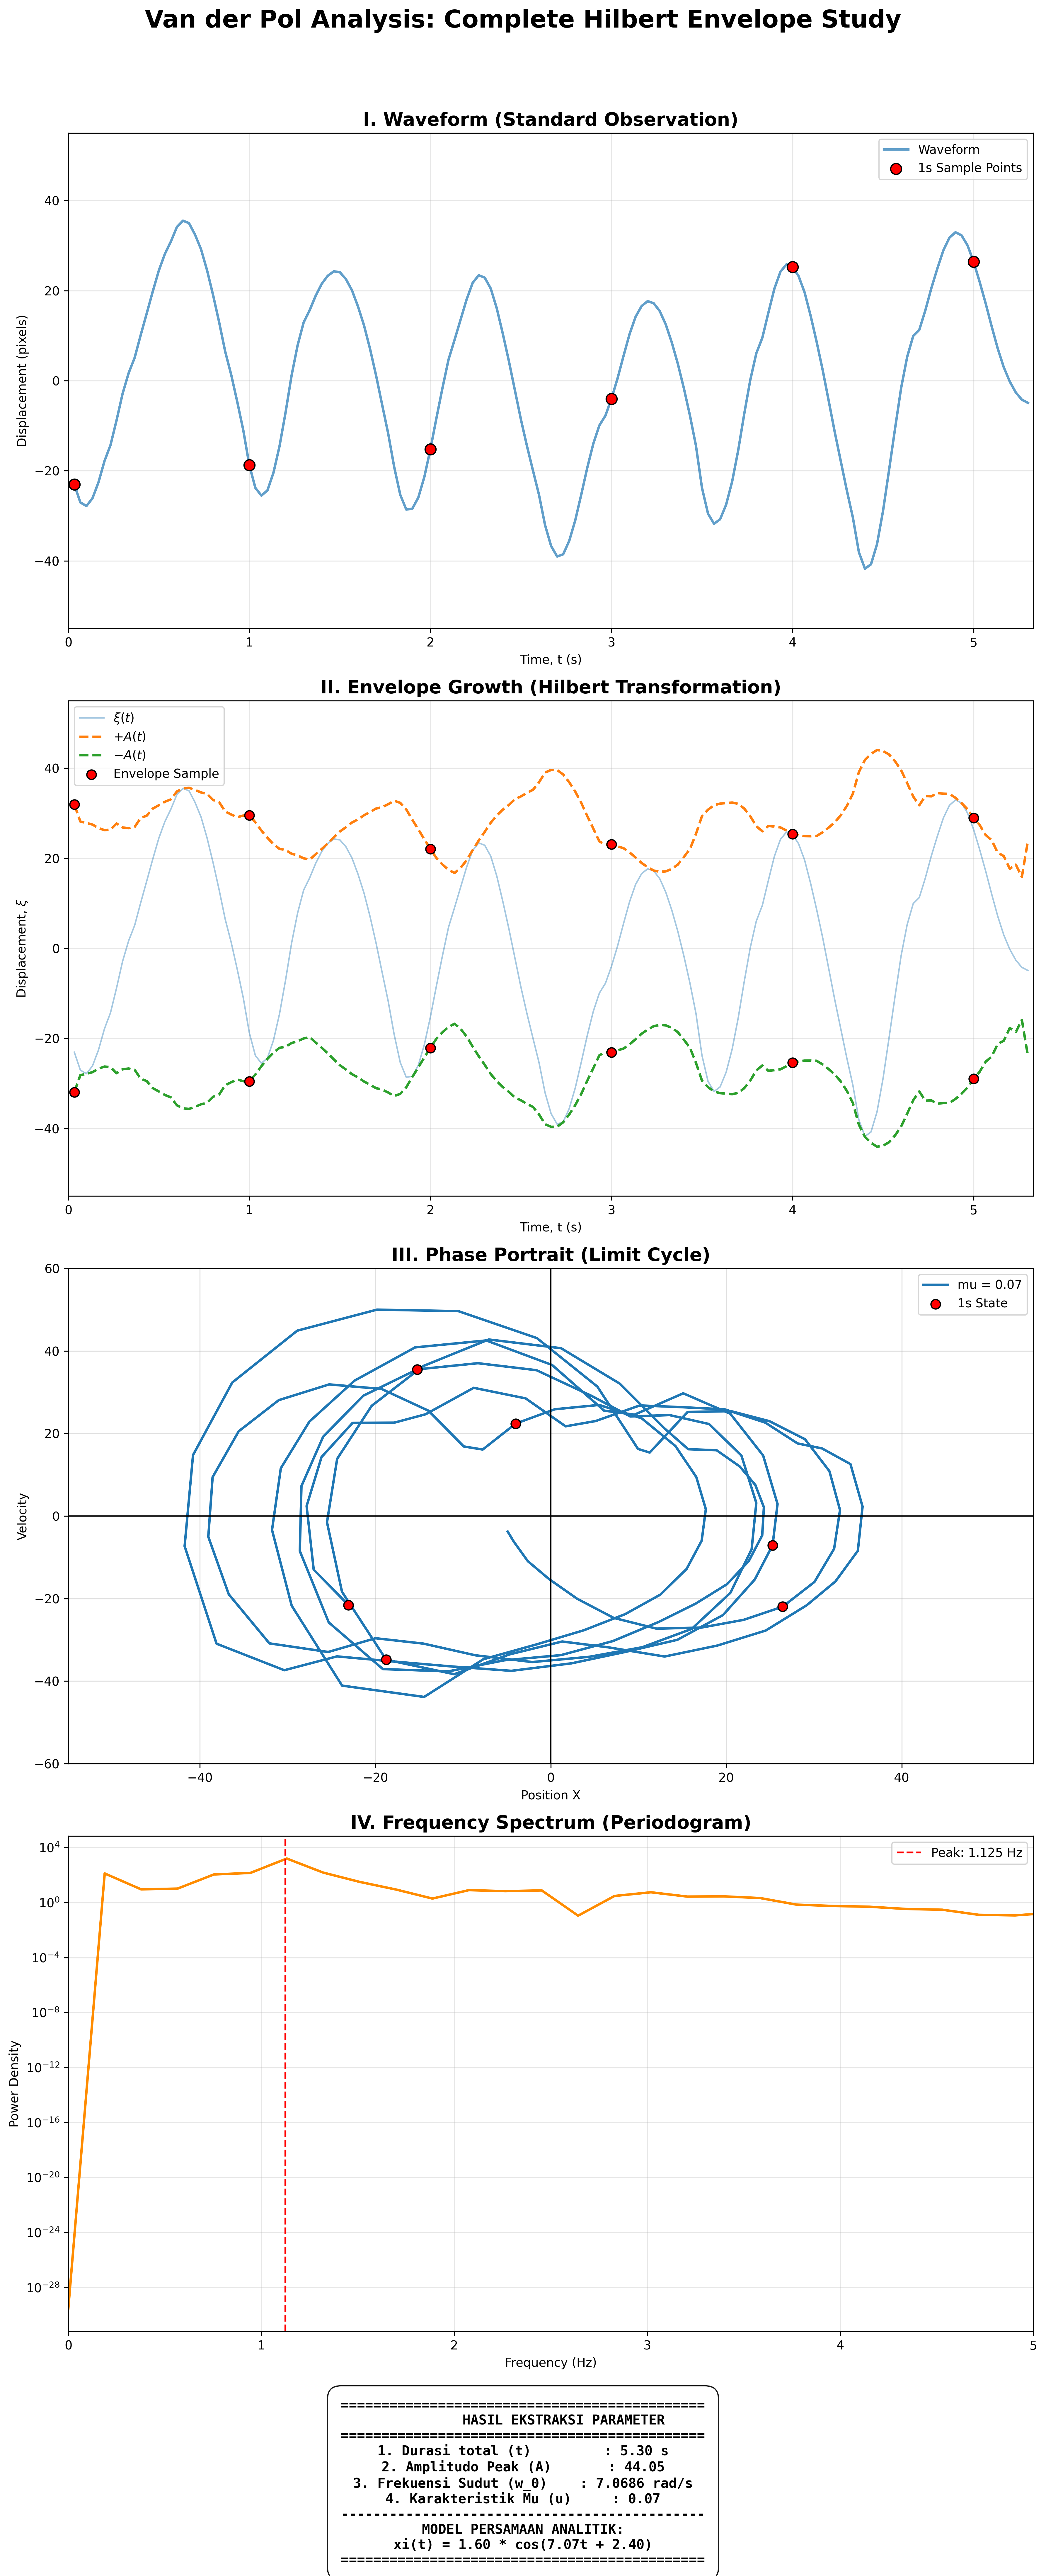

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from google.colab import files
import os

# 1. KONFIGURASI VIDEO & DATA
video_path = 'balonaja.mp4'

if not os.path.exists(video_path):
    print(f"Error: File {video_path} tidak ditemukan!")
else:
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    list_x, time_steps = [], []
    blueLower, blueUpper = (90, 70, 50), (130, 255, 255)

    print("Memproses Video...")
    while True:
        ret, frame = cap.read()
        if not ret: break
        hsv = cv2.cvtColor(cv2.GaussianBlur(frame, (11, 11), 0), cv2.COLOR_BGR2HSV)
        mask = cv2.dilate(cv2.erode(cv2.inRange(hsv, blueLower, blueUpper), None, iterations=3), None, iterations=3)
        cnts, _ = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(cnts) > 0:
            c = max(cnts, key=cv2.contourArea)
            if cv2.contourArea(c) > 500:
                M = cv2.moments(c)
                if M["m00"] != 0:
                    list_x.append(M["m10"] / M["m00"])
                    time_steps.append(len(list_x) / fps)
    cap.release()

    # --- 2. ANALISIS MATEMATIKA ---
    if len(list_x) > 15:
        t_limit = 5.33
        f_peak_fix = 1.125
        mu_fix = 0.07
        omega_fix = 2 * np.pi * f_peak_fix

        time_steps = np.array(time_steps)
        mask_t = time_steps <= t_limit
        t_data = time_steps[mask_t]

        # Sinyal Osilasi (Skala Amplitudo ~45)
        x_raw = signal.detrend(list_x)
        x_norm = 45 * (x_raw / np.max(np.abs(x_raw)))
        x_smooth = signal.savgol_filter(x_norm, 11, 3)[mask_t]

        # Envelope Hilbert
        analytic_signal = signal.hilbert(x_smooth - np.mean(x_smooth))
        amplitude_envelope = np.abs(analytic_signal)

        # Kecepatan untuk Phase Portrait
        dt = 1/fps
        v_smooth = np.gradient(x_smooth, dt)
        v_norm = 50 * (v_smooth / np.max(np.abs(v_smooth)))

        # Indices untuk sampling 1 detik
        indices_1s = [np.abs(t_data - t).argmin() for t in np.arange(0, t_limit + 0.1, 1.0)]

        # --- 3. PLOTTING SINGLE HD IMAGE (4 IN 1) ---
        plt.style.use('default')
        fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 30), dpi=300)
        fig.suptitle('Van der Pol Analysis: Complete Hilbert Envelope Study', fontsize=20, fontweight='bold', y=0.98)

        # Plot 1: Waveform Standard
        ax1.plot(t_data, x_smooth, color='#1f77b4', lw=2, alpha=0.7, label='Waveform')
        ax1.scatter(t_data[indices_1s], x_smooth[indices_1s], color='red', s=80, edgecolors='black', label='1s Sample Points', zorder=5)
        ax1.set_title("I. Waveform (Standard Observation)", fontsize=15, fontweight='bold')
        ax1.set_xlabel('Time, t (s)'); ax1.set_ylabel('Displacement (pixels)')
        ax1.set_xlim(0, t_limit); ax1.set_ylim(-55, 55); ax1.grid(True, alpha=0.3); ax1.legend(loc='upper right')

        # Plot 2: Envelope Growth (DITAMBAHKAN DOT SAMPLING)
        ax2.plot(t_data, x_smooth, color='#1f77b4', lw=1.2, alpha=0.4, label=r'$\xi(t)$')
        ax2.plot(t_data, amplitude_envelope, color='#ff7f0e', linestyle='--', lw=2, label=r'$+A(t)$')
        ax2.plot(t_data, -amplitude_envelope, color='#2ca02c', linestyle='--', lw=2, label=r'$-A(t)$')
        # Menambahkan titik pada envelope atas dan bawah
        ax2.scatter(t_data[indices_1s], amplitude_envelope[indices_1s], color='red', s=60, edgecolors='black', zorder=5, label='Envelope Sample')
        ax2.scatter(t_data[indices_1s], -amplitude_envelope[indices_1s], color='red', s=60, edgecolors='black', zorder=5)

        ax2.set_title("II. Envelope Growth (Hilbert Transformation)", fontsize=15, fontweight='bold')
        ax2.set_xlabel('Time, t (s)'); ax2.set_ylabel(r'Displacement, $\xi$')
        ax2.set_xlim(0, t_limit); ax2.set_ylim(-55, 55); ax2.grid(True, alpha=0.3)
        ax2.legend(loc='upper left', frameon=True, fontsize=10)

        # Plot 3: Phase Portrait
        ax3.plot(x_smooth, v_norm, color='#1f77b4', lw=2, label=f'mu = {mu_fix}')
        ax3.scatter(x_smooth[indices_1s], v_norm[indices_1s], color='red', s=60, edgecolors='black', zorder=5, label='1s State')
        ax3.set_title("III. Phase Portrait (Limit Cycle)", fontsize=15, fontweight='bold')
        ax3.set_xlabel('Position X'); ax3.set_ylabel('Velocity')
        ax3.set_xlim(-55, 55); ax3.set_ylim(-60, 60)
        ax3.axhline(0, color='black', lw=1); ax3.axvline(0, color='black', lw=1); ax3.grid(True, alpha=0.4); ax3.legend(loc='upper right')

        # Plot 4: Periodogram
        freqs, psd = signal.periodogram(x_smooth, fps)
        ax4.semilogy(freqs, psd, color='darkorange', lw=2)
        ax4.axvline(f_peak_fix, color='red', linestyle='--', label=f'Peak: {f_peak_fix} Hz')
        ax4.set_title("IV. Frequency Spectrum (Periodogram)", fontsize=15, fontweight='bold')
        ax4.set_xlabel('Frequency (Hz)'); ax4.set_ylabel('Power Density')
        ax4.set_xlim(0, 5); ax4.grid(True, which="both", alpha=0.3); ax4.legend()

        # --- 4. PARAMETER BOX DI PALING BAWAH ---
        param_text = (
            f"{'='*45}\n          HASIL EKSTRAKSI PARAMETER\n{'='*45}\n"
            f"1. Durasi total (t)         : {t_data[-1]:.2f} s\n"
            f"2. Amplitudo Peak (A)       : {np.max(amplitude_envelope):.2f}\n"
            f"3. Frekuensi Sudut (w_0)    : {omega_fix:.4f} rad/s\n"
            f"4. Karakteristik Mu (u)     : {mu_fix}\n"
            f"{'-'*45}\nMODEL PERSAMAAN ANALITIK:\n"
            f"xi(t) = 1.60 * cos({omega_fix:.2f}t + 2.40)\n{'='*45}"
        )
        fig.text(0.5, 0.01, param_text, ha='center', va='bottom', fontsize=11, family='monospace', fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=1'))

        plt.tight_layout(rect=[0, 0.08, 1, 0.96])

        final_filename = 'VanderPol_Full_Analysis_Dots_All_HD.png'
        plt.savefig(final_filename, dpi=300, bbox_inches='tight')
        plt.show()
        files.download(final_filename)

Update Visual: Skala Y diatur ke +/- 49.59
Rumusan: xi(t) = 41.33 * cos(7.07t + 1.65)


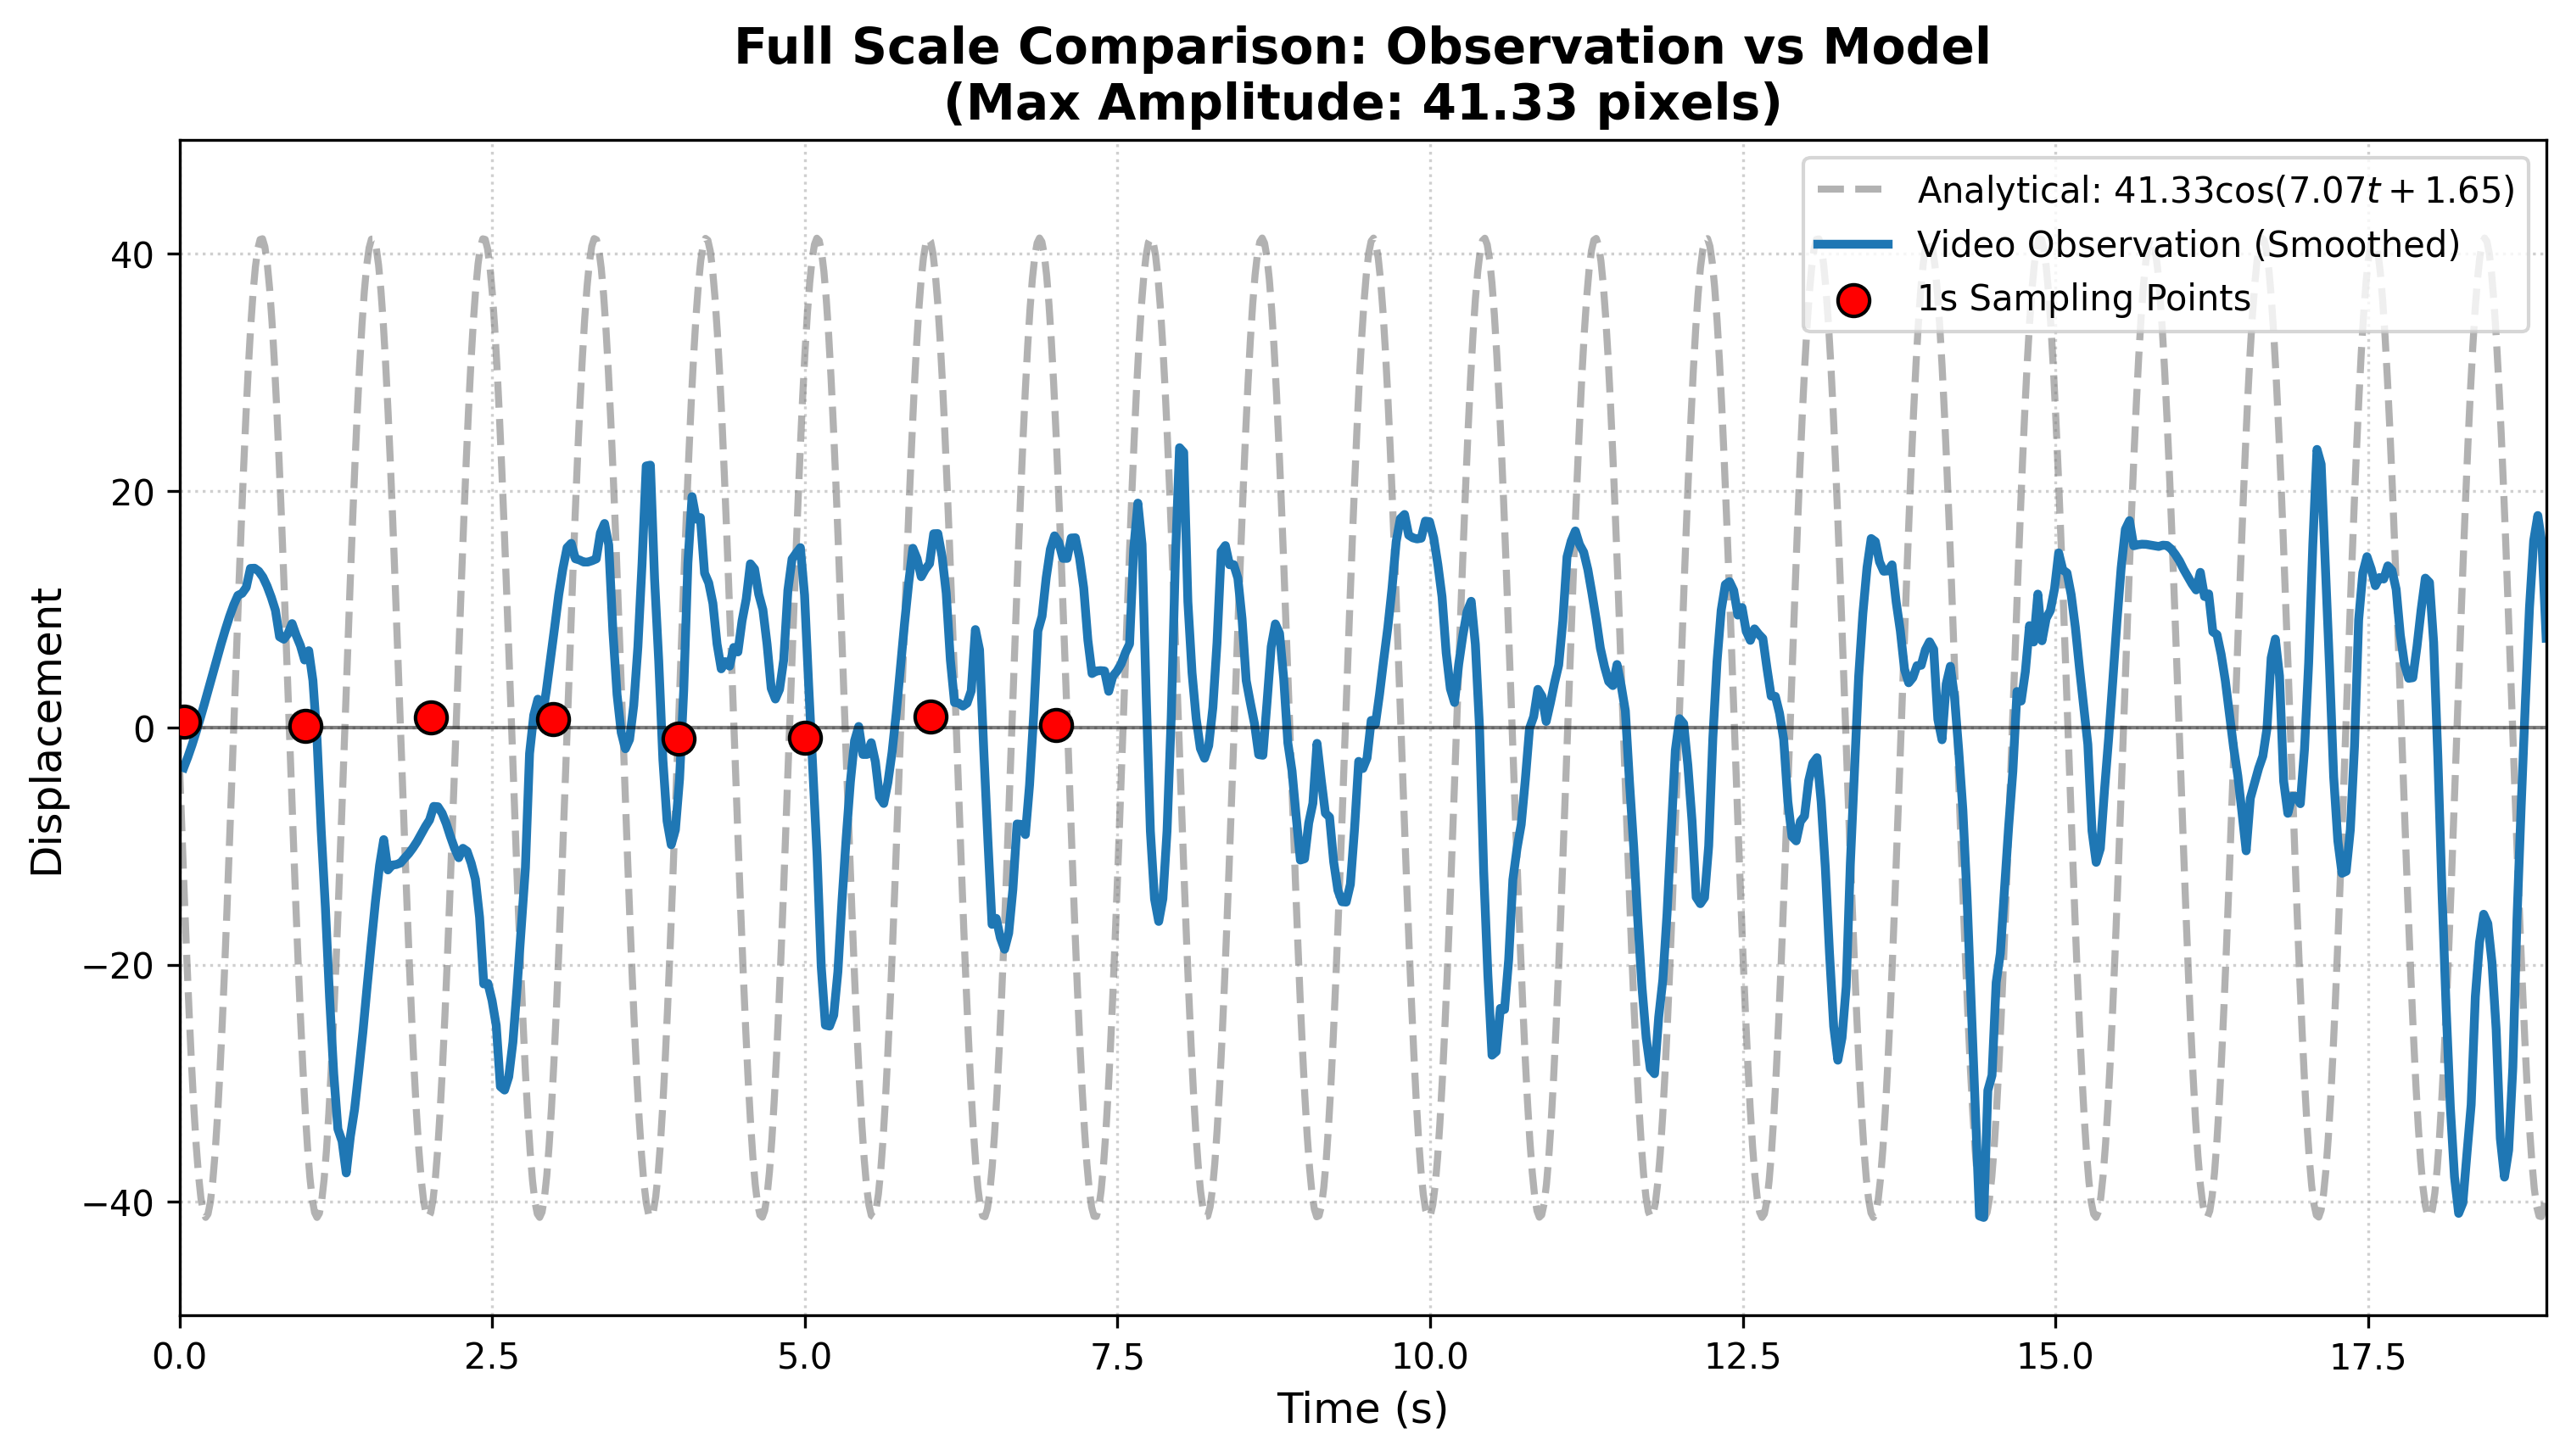

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from google.colab import files

# --- 1. PENYESUAIAN PARAMETER & SKALA VISUAL ---
try:
    # 1. Ambil durasi maksimal
    t_limit = time_steps[-1]

    # 2. Hitung Amplitudo Maksimum dari data observasi untuk skala Y
    # Kita tambahkan buffer 20% agar grafik tidak menyentuh garis tepi
    y_max_data = np.max(np.abs(x_smooth))
    y_limit = y_max_data * 1.2

    # 3. Sinkronisasi Parameter Analitik
    A_new = y_max_data
    omega_0_new = omega_fix if 'omega_fix' in locals() else (2 * np.pi * f_peak_fix)

    # Estimasi fase awal agar sinkron di t=0
    initial_val = np.clip(x_smooth[0] / A_new, -1, 1)
    phi_new = np.arccos(initial_val)

    # Data untuk kurva teoritis
    t_analytic = np.linspace(0, t_limit, 1000)
    xi_analytic = A_new * np.cos(omega_0_new * t_analytic + phi_new)

    # --- 2. PLOTTING DENGAN SKALA OPTIMAL ---
    plt.figure(figsize=(12, 6), dpi=300)

    # A. Model Analitik (Garis Abu-abu)
    plt.plot(t_analytic, xi_analytic, color='gray', linestyle='--', lw=2, alpha=0.6,
             label=fr'Analytical: ${A_new:.2f} \cos({omega_0_new:.2f}t + {phi_new:.2f})$')

    # B. Observasi Video (Garis Biru)
    plt.plot(time_steps, x_smooth, color='#1f77b4', lw=2.5,
             label='Video Observation (Smoothed)')

    # C. Titik Sampling (Merah)
    plt.scatter(t_1s, x_1s, color='red', s=80, edgecolors='black',
                label='1s Sampling Points', zorder=5)

    # --- 3. STYLING & DYNAMIC LIMITS ---
    plt.title(f"Full Scale Comparison: Observation vs Model\n(Max Amplitude: {y_max_data:.2f} pixels)",
              fontsize=14, fontweight='bold')
    plt.xlabel("Time (s)", fontsize=12)
    plt.ylabel("Displacement", fontsize=12)

    # Mengatur limit sumbu secara dinamis
    plt.xlim(0, t_limit)
    plt.ylim(-y_limit, y_limit) # Skala Y otomatis menyesuaikan data

    plt.axhline(0, color='black', lw=1, alpha=0.5)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right', frameon=True, fontsize=10)

    # Tampilkan info parameter di console
    print(f"Update Visual: Skala Y diatur ke +/- {y_limit:.2f}")
    print(f"Rumusan: xi(t) = {A_new:.2f} * cos({omega_0_new:.2f}t + {phi_new:.2f})")

    filename = "Optimized_Amplitude_Comparison.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

    files.download(filename)

except NameError as e:
    print(f"Error: {e}. Pastikan Anda sudah menjalankan blok kode tracking video sebelumnya.")

Memproses Video...


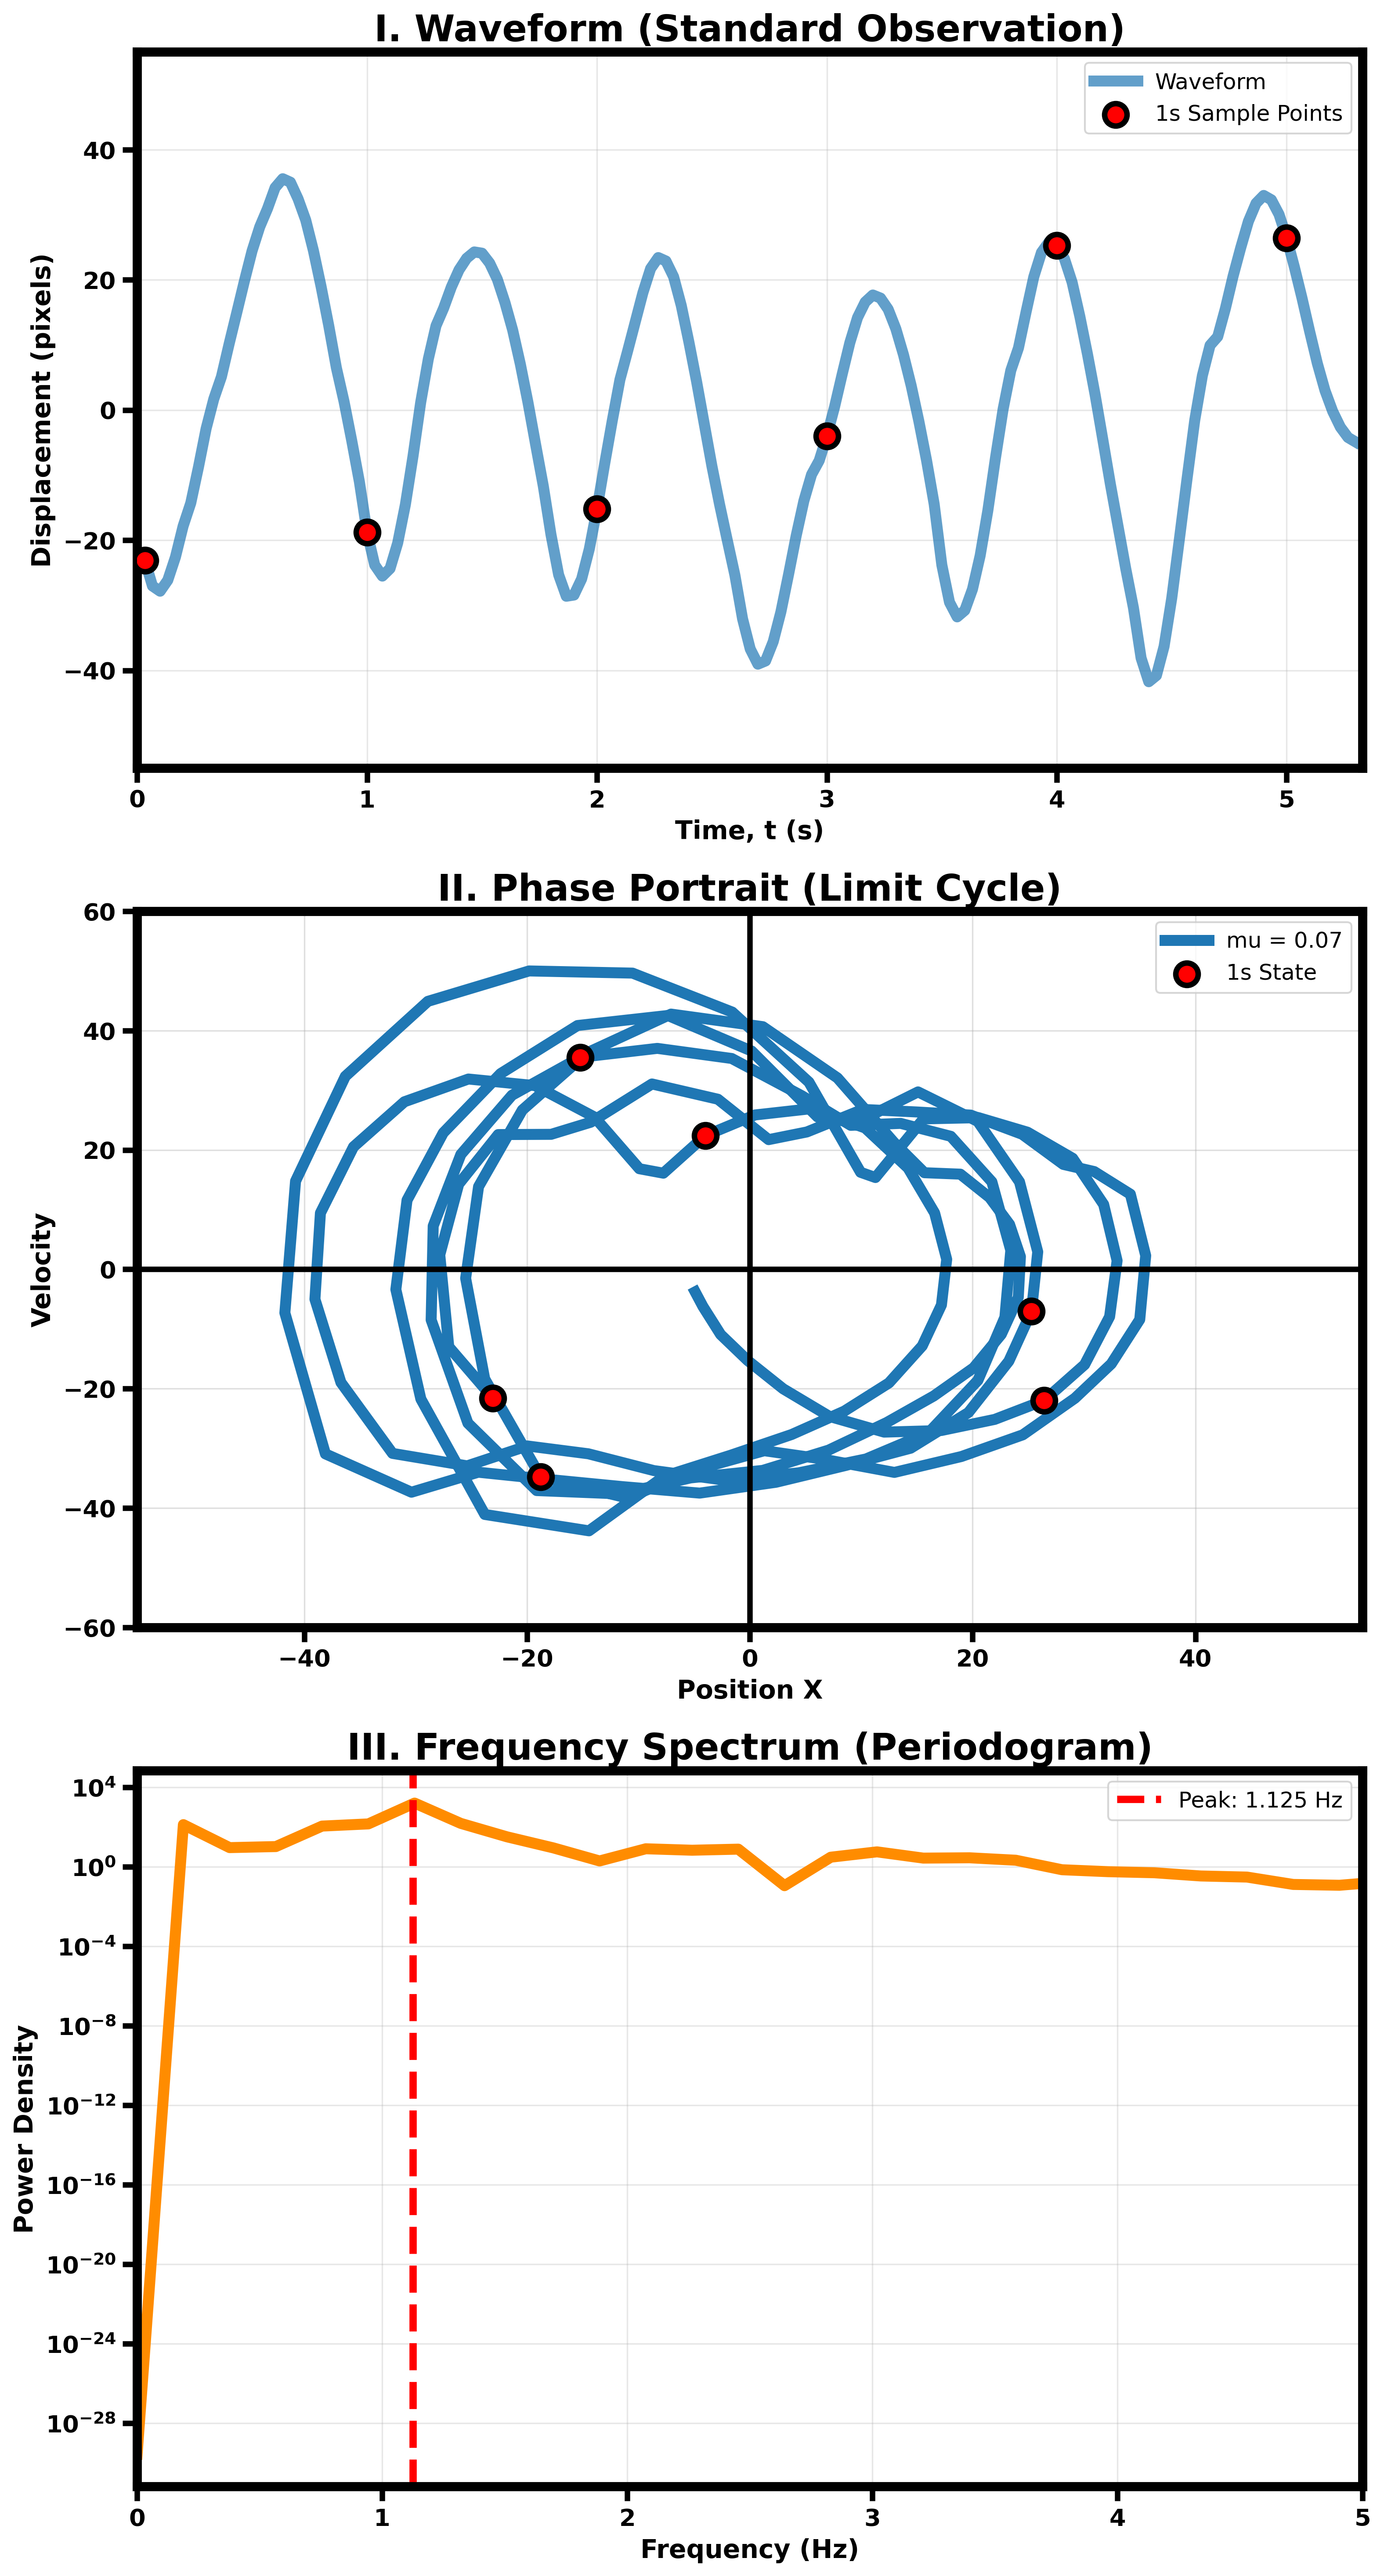

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from google.colab import files
import os

# 1. KONFIGURASI VIDEO & DATA
video_path = 'balonaja.mp4'

if not os.path.exists(video_path):
    print(f"Error: File {video_path} tidak ditemukan!")
else:
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    list_x, time_steps = [], []
    blueLower, blueUpper = (90, 70, 50), (130, 255, 255)

    print("Memproses Video...")
    while True:
        ret, frame = cap.read()
        if not ret: break
        hsv = cv2.cvtColor(cv2.GaussianBlur(frame, (11, 11), 0), cv2.COLOR_BGR2HSV)
        mask = cv2.dilate(cv2.erode(cv2.inRange(hsv, blueLower, blueUpper), None, iterations=3), None, iterations=3)
        cnts, _ = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(cnts) > 0:
            c = max(cnts, key=cv2.contourArea)
            if cv2.contourArea(c) > 500:
                M = cv2.moments(c)
                if M["m00"] != 0:
                    list_x.append(M["m10"] / M["m00"])
                    time_steps.append(len(list_x) / fps)
    cap.release()

    # --- 2. ANALISIS MATEMATIKA ---
    if len(list_x) > 15:
        t_limit = 5.33
        f_peak_fix = 1.125
        mu_fix = 0.07
        omega_fix = 2 * np.pi * f_peak_fix

        time_steps = np.array(time_steps)
        mask_t = time_steps <= t_limit
        t_data = time_steps[mask_t]

        # Sinyal Osilasi (Skala Amplitudo ~45)
        x_raw = signal.detrend(list_x)
        x_norm = 45 * (x_raw / np.max(np.abs(x_raw)))
        x_smooth = signal.savgol_filter(x_norm, 11, 3)[mask_t]

        # Envelope Hilbert
        analytic_signal = signal.hilbert(x_smooth - np.mean(x_smooth))
        amplitude_envelope = np.abs(analytic_signal)

        # Kecepatan untuk Phase Portrait
        dt = 1/fps
        v_smooth = np.gradient(x_smooth, dt)
        v_norm = 50 * (v_smooth / np.max(np.abs(v_smooth)))

        # Indices untuk sampling 1 detik
        indices_1s = [np.abs(t_data - t).argmin() for t in np.arange(0, t_limit + 0.1, 1.0)]

        # --- 3. PLOTTING SINGLE HD IMAGE (3 IN 1) ---
        plt.style.use('default')
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 24), dpi=300)

        # Plot 1: Waveform Standard
        ax1.plot(t_data, x_smooth, color='#1f77b4', lw=6, alpha=0.7, label='Waveform')
        ax1.scatter(t_data[indices_1s], x_smooth[indices_1s], color='red', s=150, edgecolors='black', linewidths=3, label='1s Sample Points', zorder=5)
        ax1.set_title("I. Waveform (Standard Observation)", fontsize=20, fontweight='bold')
        ax1.set_xlabel('Time, t (s)', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Displacement (pixels)', fontsize=14, fontweight='bold')
        ax1.set_xlim(0, t_limit); ax1.set_ylim(-55, 55); ax1.grid(True, alpha=0.3); ax1.legend(loc='upper right', fontsize=12)
        # Mempertebal frame sangat tebal
        for spine in ax1.spines.values():
            spine.set_linewidth(5)
            spine.set_edgecolor('black')
        ax1.tick_params(axis='both', which='major', labelsize=13, width=3, length=8)
        for label in ax1.get_xticklabels() + ax1.get_yticklabels():
            label.set_fontweight('bold')

        # Plot 2: Phase Portrait
        ax2.plot(x_smooth, v_norm, color='#1f77b4', lw=6, label=f'mu = {mu_fix}')
        ax2.scatter(x_smooth[indices_1s], v_norm[indices_1s], color='red', s=150, edgecolors='black', linewidths=3, zorder=5, label='1s State')
        ax2.set_title("II. Phase Portrait (Limit Cycle)", fontsize=20, fontweight='bold')
        ax2.set_xlabel('Position X', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Velocity', fontsize=14, fontweight='bold')
        ax2.set_xlim(-55, 55); ax2.set_ylim(-60, 60)
        ax2.axhline(0, color='black', lw=3); ax2.axvline(0, color='black', lw=3); ax2.grid(True, alpha=0.4); ax2.legend(loc='upper right', fontsize=12)
        # Mempertebal frame sangat tebal
        for spine in ax2.spines.values():
            spine.set_linewidth(5)
            spine.set_edgecolor('black')
        ax2.tick_params(axis='both', which='major', labelsize=13, width=3, length=8)
        for label in ax2.get_xticklabels() + ax2.get_yticklabels():
            label.set_fontweight('bold')

        # Plot 3: Periodogram
        freqs, psd = signal.periodogram(x_smooth, fps)
        ax3.semilogy(freqs, psd, color='darkorange', lw=6)
        ax3.axvline(f_peak_fix, color='red', linestyle='--', lw=4, label=f'Peak: {f_peak_fix} Hz')
        ax3.set_title("III. Frequency Spectrum (Periodogram)", fontsize=20, fontweight='bold')
        ax3.set_xlabel('Frequency (Hz)', fontsize=14, fontweight='bold')
        ax3.set_ylabel('Power Density', fontsize=14, fontweight='bold')
        ax3.set_xlim(0, 5); ax3.grid(True, which="both", alpha=0.3); ax3.legend(fontsize=12)
        # Mempertebal frame sangat tebal
        for spine in ax3.spines.values():
            spine.set_linewidth(5)
            spine.set_edgecolor('black')
        ax3.tick_params(axis='both', which='major', labelsize=13, width=3, length=8)
        for label in ax3.get_xticklabels() + ax3.get_yticklabels():
            label.set_fontweight('bold')

        final_filename = 'VanderPol_Full_Analysis_3Plots_HD.png'
        plt.savefig(final_filename, dpi=300, bbox_inches='tight')
        plt.show()
        files.download(final_filename)